In [271]:
import pandas as pd
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt


import pymc as pm
import arviz as az

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, minmax_scale

from gurobipy import *
import pytensor.tensor as pt

import joblib
from joblib import Parallel, delayed
import multiprocessing as mp
from collections import Counter
import collections
import random
from tqdm import tqdm
from scipy.special import expit

## Utils


In [ ]:
def clean_data(players_preds, valid_player_ids):
    print('starting to clean data...')
    players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
    gk_data = players_preds[players_preds['position'] == 'GK'][feats_cols_gk] #[data_cols_gk]
    def_data = players_preds[players_preds['position'] == 'DEF'][feats_cols_def]#[data_cols]
    mid_data = players_preds[players_preds['position'] == 'MID'][feats_cols_mid].dropna()#[data_cols]
    fwd_data = players_preds[players_preds['position'] == 'FWD'][feats_cols_fwd].dropna()#[data_cols]
    data = [gk_data, def_data, mid_data, fwd_data]

    gk_data = gk_data.dropna()
    def_data = def_data.dropna()
    mid_data = mid_data.dropna()
    fwd_data = fwd_data.dropna()

    # GK
    gk_data['transfers_in_log'] = gk_data['transfers_in'].apply(lambda x: np.log(x + 1))

    gk_data['transfers_out_log'] = gk_data['transfers_out'].apply(lambda x: np.log(x + 1))
    gk_data['selected_log'] = gk_data['ownership_percent'].apply(lambda x: np.log(x + 1))

    # xg_times_transfers = xG_5 * transfers_in
    gk_data['saves_times_transfers'] = gk_data['saves_5'] * gk_data['transfers_in_log']
    # points1_times_transfers = total_points_1 * transfers_in
    gk_data['points1_times_transfers'] = gk_data['total_points_1'] * gk_data['transfers_in_log']

    gk_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)


    # DEF
    def_data['transfers_in_log'] = def_data['transfers_in'].apply(lambda x: np.log(x + 1))

    def_data['transfers_out_log'] = def_data['transfers_out'].apply(lambda x: np.log(x + 1))
    def_data['selected_log'] = def_data['ownership_percent'].apply(lambda x: np.log(x + 1))

    # xg_times_transfers = xG_5 * transfers_in
    def_data['xa_times_transfers'] = def_data['xA_5'] * def_data['transfers_in_log']
    # points1_times_transfers = total_points_1 * transfers_in
    def_data['points1_times_transfers'] = def_data['total_points_1'] * def_data['transfers_in_log']

    def_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)

    # MID
    mid_data['transfers_in_log'] = mid_data['transfers_in'].apply(lambda x: np.log(x + 1))

    mid_data['transfers_out_log'] = mid_data['transfers_out'].apply(lambda x: np.log(x + 1))
    mid_data['selected_log'] = mid_data['ownership_percent'].apply(lambda x: np.log(x + 1))

    # xg_times_transfers = xG_5 * transfers_in
    mid_data['npxg_times_transfers'] = mid_data['npxG_5'] * mid_data['transfers_in_log']
    # points1_times_transfers = total_points_1 * transfers_in
    mid_data['points1_times_transfers'] = mid_data['total_points_1'] * mid_data['transfers_in_log']

    mid_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)


    # FWD
    fwd_data['transfers_in_log'] = fwd_data['transfers_in'].apply(lambda x: np.log(x + 1))

    fwd_data['transfers_out_log'] = fwd_data['transfers_out'].apply(lambda x: np.log(x + 1))
    fwd_data['selected_log'] = fwd_data['ownership_percent'].apply(lambda x: np.log(x + 1))

    # xg_times_transfers = xG_5 * transfers_in
    fwd_data['npxg_times_transfers'] = fwd_data['npxG_5'] * fwd_data['transfers_in_log']
    # points1_times_transfers = total_points_1 * transfers_in
    fwd_data['points1_times_transfers'] = fwd_data['total_points_1'] * fwd_data['transfers_in_log']

    fwd_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)

    # Get attributes
    g_prices = gk_data['value'].tolist() #*10
    d_prices = def_data['value'].tolist() #*10
    m_prices = mid_data['value'].tolist() #*10
    f_prices = fwd_data['value'].tolist() #*10
    prices = [g_prices, d_prices, m_prices, f_prices]
    # print(g_prices, len(d_prices), len(m_prices), len(f_prices))
    # print(len(g_prices), len(d_prices), len(m_prices), len(f_prices))

    g_xPts = players_preds[players_preds['position'] == 'GK']['xP_preds'].tolist()
    d_xPts = players_preds[players_preds['position'] == 'DEF']['xP_preds'].tolist()
    m_xPts = players_preds[players_preds['position'] == 'MID']['xP_preds'].tolist()
    f_xPts = players_preds[players_preds['position'] == 'FWD']['xP_preds'].tolist()
    xPts = [g_xPts, d_xPts, m_xPts, f_xPts]

    g_teams = players_preds[players_preds['position'] == 'GK']['player_team'].tolist()
    d_teams = players_preds[players_preds['position'] == 'DEF']['player_team'].tolist()
    m_teams = players_preds[players_preds['position'] == 'MID']['player_team'].tolist()
    f_teams = players_preds[players_preds['position'] == 'FWD']['player_team'].tolist()
    teams = [g_teams, d_teams, m_teams, f_teams]

    g_positions = players_preds[players_preds['position'] == 'GK']['position'].tolist()
    d_positions = players_preds[players_preds['position'] == 'DEF']['position'].tolist()
    m_positions = players_preds[players_preds['position'] == 'MID']['position'].tolist()
    f_positions = players_preds[players_preds['position'] == 'FWD']['position'].tolist()
    positions = [g_positions, d_positions, m_positions, f_positions]

    g_ids = players_preds[players_preds['position'] == 'GK']['FPL_ID'].tolist()
    d_ids = players_preds[players_preds['position'] == 'DEF']['FPL_ID'].tolist()
    m_ids = players_preds[players_preds['position'] == 'MID']['FPL_ID'].tolist()
    f_ids = players_preds[players_preds['position'] == 'FWD']['FPL_ID'].tolist()
    ids = [g_ids, d_ids, m_ids, f_ids]

    gk_data = gk_data.select_dtypes(include=[np.number])
    gk_data = pd.DataFrame(minmax_scale(gk_data), columns=gk_data.columns, index=gk_data.index)

    def_data = def_data.select_dtypes(include=[np.number])
    # Data
    def_data = pd.DataFrame(minmax_scale(def_data), columns=def_data.columns, index=def_data.index)

    mid_data = mid_data.select_dtypes(include=[np.number])
    mid_data = pd.DataFrame(minmax_scale(mid_data), columns=mid_data.columns, index=mid_data.index)

    fwd_data = fwd_data.select_dtypes(include=[np.number])
    fwd_data = pd.DataFrame(minmax_scale(fwd_data), columns=fwd_data.columns, index=fwd_data.index)

    # Selection percentages
    gk_select_by = gk_data['ownership_percent']
    def_select_by = def_data['ownership_percent']
    mid_select_by = mid_data['ownership_percent']
    fwd_select_by = fwd_data['ownership_percent']

    gk_data = gk_data.drop(columns='ownership_percent')
    def_data = def_data.drop(columns='ownership_percent')
    mid_data = mid_data.drop(columns='ownership_percent')
    fwd_data = fwd_data.drop(columns='ownership_percent')

    # Normalise the select_percts to get the working probs
    gk_probs = gk_select_by/np.sum(gk_select_by)
    def_probs = def_select_by/np.sum(def_select_by)
    mid_probs = mid_select_by/np.sum(mid_select_by)
    fwd_probs = fwd_select_by/np.sum(fwd_select_by)

    # 1. Define a small constant (epsilon) to replace the zeros
    epsilon = 1e-9 # A very small number

    # 2. Replace all zeros with this small number
    gk_probs[gk_probs == 0] = epsilon
    def_probs[def_probs == 0] = epsilon
    mid_probs[mid_probs == 0] = epsilon
    fwd_probs[fwd_probs == 0] = epsilon


    # print(gk_data.shape)

    X_gk = pd.DataFrame(scaler_gk.transform(gk_data.values), columns=gk_data.columns)
    X_def = pd.DataFrame(scaler_def.transform(def_data.values), columns=def_data.columns)
    X_mid = pd.DataFrame(scaler_mid.transform(mid_data.values), columns=mid_data.columns)
    X_fwd = pd.DataFrame(scaler_fwd.transform(fwd_data.values), columns=fwd_data.columns)

    # print(X_mid.columns)

    # 3. Fit PCA and transform
    X_gk_pca = pd.DataFrame(pca_gk.transform(X_gk))
    X_def_pca = pd.DataFrame(pca_def.transform(X_def))
    X_mid_pca = pd.DataFrame(pca_mid.transform(X_mid))
    X_fwd_pca = pd.DataFrame(pca_fwd.transform(X_fwd))

    X_pca = [X_gk, X_def, X_mid, X_fwd]

    print('data successfully cleaned...')

    return data, prices, xPts, positions ,teams, ids, X_pca

def generate_probs(X_pca, betas):
    print('starting to generate selction probabilities')
    def safe_alpha(X_pca, beta):
        raw_scores = pm.math.dot(X_pca, beta.T)
        raw_scores -= pm.math.max(raw_scores)
        alpha = pm.math.exp(raw_scores) + 1e-3
        alpha = pm.math.clip(alpha, 1e-3, 1e3)
        return alpha


    alpha_g = safe_alpha(X_pca[0], betas[0].T)
    alpha_d = safe_alpha(X_pca[1], betas[1].T)
    alpha_m = safe_alpha(X_pca[2], betas[2].T)
    alpha_f = safe_alpha(X_pca[3], betas[3].T)

    with pm.Model():
        pg = pm.Dirichlet("pg", a=alpha_g)  # Ensure correct shape
        pd_ = pm.Dirichlet("pd_", a=alpha_d)  # Ensure correct shape
        pmid = pm.Dirichlet("pm", a=alpha_m)  # Ensure correct shape
        pf = pm.Dirichlet("pf", a=alpha_f)  # Ensure correct shape

        trace = pm.sample()

    # Extract posterior means
    pgk, pdef, pmid, pfwd = (
        trace.posterior["pg"].mean(dim=("chain", "draw")).values,
        trace.posterior["pd_"].mean(dim=("chain", "draw")).values,
        trace.posterior["pm"].mean(dim=("chain", "draw")).values,
        trace.posterior["pf"].mean(dim=("chain", "draw")).values)

    return pgk, pdef, pmid, pfwd

def is_feasible(portfolio, budget, budget_lower_bound, costs, teams):
    """
    Placeholder function to check if a portfolio is feasible.
    [span_6](start_span)[span_7](start_span)This checks the budget constraint and other linear constraints represented by W[span_6](end_span)[span_7](end_span).
    In a real scenario, this would include checks for positional limits (e.g., exactly 1 QB).
    """
    costs_ = []
    for sublist in costs:
        costs_.extend(sublist)

    costs = costs_
    # print(portfolio, costs)
    total_cost = np.dot(portfolio, costs)
    print('*************', total_cost)

    # teams = pd.concat(teams).values
    # print(teams)
    if total_cost > budget or total_cost < budget_lower_bound:
        return False
    # Add other positional/diversity constraint checks here
    print(total_cost, budget_lower_bound)

    # --- Max 3 players per team ---
    team_counts = {}
    teams_ = []
    for sublist in teams:
        teams_.extend(sublist)

    teams = teams_

    team_idx = [idx for idx, _ in enumerate(portfolio) if portfolio[idx] == 1]
    selected_teams = [teams[i] for i in team_idx]

    if any(team >3 for team in Counter(selected_teams).values()):
        return False
    print(total_cost)
    return True

def get_random_fpl_formation():
    """
    Generates all valid 11-player FPL formations and returns one at random.
    """
    def_sizes = [3, 4, 5]
    mid_sizes = [2, 3, 4, 5]
    fwd_sizes = [1, 2, 3]

    valid_formations = []

    # Iterate through all combinations to find those that sum to 10 (plus 1 GK)
    for def_ in def_sizes:
        for mid in mid_sizes:
            for fwd in fwd_sizes:
                if def_ + mid + fwd == 10:
                    valid_formations.append([def_, mid, fwd])

    # Return a single random choice from the list
    return random.choice(valid_formations)

def generate_one_team(ids, beta_estimates, num_dirichlet_samples, p_vectors, positional_teams, q, xp_pred, costs, budget, Blb_ratio, total_num_players):
    # print('Hellllo....')
    reject = True
    # --- PERFORMANCE FIX 2 & 3: Calculate constants *before* the loop ---
    XP_THRESHOLD = np.percentile(np.concatenate(list(xp_pred.values())), 75)
    budget_lower_bound = budget * Blb_ratio

    ids_ = []
    for sublist in ids:
        ids_.extend(sublist)

    # Sample new betas, alphas, and p_vectors *for this attempt*
    beta_samples = {}
    for pos, trace in beta_estimates.items():
        # Get a random sample index
        sample_idx = np.random.randint(0, trace.shape[0])
        # Get the beta vector for that sample, shape (N_features,)
        beta_samples[pos] = trace[sample_idx]

    # p_vectors_ = {pos: precomputed_p_vectors[pos][np.random.randint(num_dirichlet_samples)]
    #     for pos in ['GK', 'DEF', 'MID', 'FWD']}

    # print(len(p_vectors_['GK']), len(p_vectors['GK']),':', len(p_vectors_['DEF']),  len(p_vectors['DEF']),':', len(p_vectors_['MID']),  len(p_vectors['MID']),':', len(p_vectors_['FWD']),  len(p_vectors['FWD']))



    # --- Get and print a random formation ---
    random_formation = get_random_fpl_formation()

    # Create an array of indices for each position
    gk_indices = np.arange(len(p_vectors['GK']))
    def_indices = np.arange(len(p_vectors['DEF']))
    mid_indices = np.arange(len(p_vectors['MID']))
    fwd_indices = np.arange(len(p_vectors['FWD']))

    # Sample player indices WITHOUT replacement
    selected_gk_indices = np.random.choice(gk_indices, size=1, replace=False, p=p_vectors['GK'])
    selected_def_indices = np.random.choice(def_indices, size=random_formation[0], replace=False, p=p_vectors['DEF'])
    selected_mid_indices = np.random.choice(mid_indices, size=random_formation[1], replace=False, p=p_vectors['MID'])
    selected_fwd_indices = np.random.choice(fwd_indices, size=random_formation[2], replace=False, p=p_vectors['FWD'])

    # --- Create the binary selection arrays ---
    # This creates the [0, 1, 0, 1, ...] format your code expects
    selected_g = np.zeros(len(p_vectors['GK']), dtype=int)
    selected_g[selected_gk_indices] = 1

    selected_d = np.zeros(len(p_vectors['DEF']), dtype=int)
    selected_d[selected_def_indices] = 1

    selected_m = np.zeros(len(p_vectors['MID']), dtype=int)
    selected_m[selected_mid_indices] = 1

    selected_f = np.zeros(len(p_vectors['FWD']), dtype=int)
    selected_f[selected_fwd_indices] = 1

    selections = {
        'GK': selected_g,
        'DEF': selected_d,
        'MID': selected_m,
        'FWD': selected_f,
    }

    # --- Step 9-11: Implement stacking logic ---
    # --- Step 4: Determine if the opponent is a "stacker" ---
    is_stacker = np.random.binomial(1, q) == 1
    if is_stacker:
        # --- FWD-MID Stack Logic ---
        if len(selected_fwd_indices) > 0 and len(selected_mid_indices) > 0:
            # 1. Find the best selected FWD to be the anchor
            best_fwd_pos_idx = max(selected_fwd_indices, key=lambda idx: xp_pred['FWD'][idx])

            # XP_THRESHOLD = np.percentile(np.concatenate(list(xp_pred.values())), 75)
            # Skip stacking if anchor player isn't good enough
            if xp_pred['FWD'][best_fwd_pos_idx] >= XP_THRESHOLD:
                # 2. Get this FWD's team
                anchor_team = positional_teams['FWD'][best_fwd_pos_idx]
                # 3. Find all available MIDs from that team
                # (Must not be one of the MIDs already selected)
                available_mid_teammate_indices = [
                    mid_idx for mid_idx in mid_indices
                    if positional_teams['MID'][mid_idx] == anchor_team and
                       mid_idx not in selected_mid_indices
                ]

                if available_mid_teammate_indices:
                    # 4. Get the probabilities for *only* these teammates
                    teammate_p_vector = p_vectors['MID'][available_mid_teammate_indices]
                    teammate_p_vector_normalized = teammate_p_vector / np.sum(teammate_p_vector)

                    if np.sum(teammate_p_vector_normalized) > 0:
                        # 5. Pick the best teammate based on their probability
                        chosen_teammate_pos_idx = np.random.choice(
                            available_mid_teammate_indices,
                            size=1,
                            p=teammate_p_vector_normalized
                        )[0]

                        # 6. Find the *worst* selected MID to replace
                        worst_mid_pos_idx = min(selected_mid_indices,
                                                key=lambda idx: xp_pred['MID'][idx])

                        # 7. Perform the swap
                        new_mid_selection_list = list(selected_mid_indices)
                        if chosen_teammate_pos_idx not in new_mid_selection_list:
                            try:
                                new_mid_selection_list.remove(worst_mid_pos_idx)
                                new_mid_selection_list.append(chosen_teammate_pos_idx)
                                selected_mid_indices = np.array(new_mid_selection_list)
                            except ValueError:
                                pass # Safety check

        # --- DEF-GK Stack Logic ---
        if len(selected_def_indices) > 0: # We always have 1 GK
            # 1. Find best selected DEF anchor
            best_def_pos_idx = max(selected_def_indices,
                                    key=lambda idx: xp_pred['DEF'][idx])

            # XP_THRESHOLD = np.percentile(np.concatenate(list(xp_pred.values())), 75)

            # Skip stacking if anchor player isn't good enough
            if xp_pred['DEF'][best_def_pos_idx] >= XP_THRESHOLD:
                # 2. Get team
                anchor_team = positional_teams['DEF'][best_def_pos_idx]

                # 3. Find available GK teammates (usually just one)
                available_gk_teammate_indices = [
                    gk_idx for gk_idx in gk_indices
                    if positional_teams['GK'][gk_idx] == anchor_team and
                        gk_idx not in selected_gk_indices
                ]

                if available_gk_teammate_indices:
                    # 4. Get probs
                    teammate_p_vector = p_vectors['GK'][available_gk_teammate_indices]
                    teammate_p_vector_normalized = teammate_p_vector / np.sum(teammate_p_vector)

                    if np.sum(teammate_p_vector_normalized) > 0:
                        # 5. Pick one
                        chosen_teammate_pos_idx = np.random.choice(
                            available_gk_teammate_indices,
                            size=1,
                            p=teammate_p_vector_normalized
                        )[0]

                        # 6. Replace the (only) selected GK
                        selected_gk_indices = np.array([chosen_teammate_pos_idx])

        # Rebuild selections after any stacking adjustments
        selections = {
            'GK': np.zeros(len(p_vectors['GK']), dtype=int),
            'DEF': np.zeros(len(p_vectors['DEF']), dtype=int),
            'MID': np.zeros(len(p_vectors['MID']), dtype=int),
            'FWD': np.zeros(len(p_vectors['FWD']), dtype=int)
        }

        selections['GK'][selected_gk_indices] = 1
        selections['DEF'][selected_def_indices] = 1
        selections['MID'][selected_mid_indices] = 1
        selections['FWD'][selected_fwd_indices] = 1

    # 1. Get the GLOBAL IDs of the selected players
    #    (ids[0] is gk_ids, ids[1] is def_ids, etc.)

    # print(selections)
    global_gk_ids = np.array(ids[0])[selected_gk_indices]
    global_def_ids = np.array(ids[1])[selected_def_indices]
    global_mid_ids = np.array(ids[2])[selected_mid_indices]
    global_fwd_ids = np.array(ids[3])[selected_fwd_indices]

    # 2. Concatenate all selected global IDs
    all_selected_global_ids = np.concatenate([
        global_gk_ids,
        global_def_ids,
        global_mid_ids,
        global_fwd_ids
    ])

    # Make a lookup dict for fast access
    id_to_index = {pid: idx for idx, pid in enumerate(np.concatenate(ids))}

    # Find positions (indices) of selected IDs
    selected_indices = [id_to_index[i] for i in all_selected_global_ids]

    print('------------->', selected_indices)

    # 3. Create the GLOBAL binary portfolio
    candidate_portfolio_global = np.zeros(total_num_players, dtype=int)
    candidate_portfolio_global[selected_indices] = 1

    if is_feasible(candidate_portfolio_global, budget, budget_lower_bound, costs, teams):

        reject = False
        squad_ids = [cid for cid, count in zip(ids_, candidate_portfolio_global) if count > 0]
        # squad_frozenset = frozenset(squad_ids)

        print('Getting sum.... ', candidate_portfolio_global )
        if np.sum(candidate_portfolio_global) == 0:
            return None
        return squad_ids

def sample_opponent_portfolios(O, batch_size, beta_estimates, feature_matrices, ids, costs, budget, teams, xp_preds, p_vectors, q=0.35, Blb_ratio=0.90):
    """
    Args:
        O (int): Number of opponent portfolios to generate.
        beta_estimates (dict): A dictionary mapping position ('QB', 'RB', etc.) to its estimated beta coefficients.
        feature_matrices (dict): A dictionary mapping position to its feature matrix X.
        costs (np.ndarray): An array of costs for all players.
        budget (float): The total salary cap.
        q (float): The probability of a "stacker" contestant.
        Blb_ratio (float): The minimum budget usage ratio.

    Returns:
        list: A list of O feasible opponent portfolios (as numpy arrays).
    """
    print(f"\nGenerating {O} opponent portfolios...")
    xp_pred = {
        'GK': xp_preds[0],
        'DEF': xp_preds[1],
        'MID': xp_preds[2],
        'FWD': xp_preds[3],
    }

    positional_teams = {
        'GK': teams[0],
        'DEF': teams[1],
        'MID': teams[2],
        'FWD': teams[3],
    }

    opponent_portfolios = set()
    attempts = 0
    max_attempts = O * 1  # prevents infinite loop

    # pre-sample a few hundred per position and reuse them
    num_dirichlet_samples = O  # try 200–1000 depending on O
    precomputed_p_vectors = {
        pos: [np.random.dirichlet(np.exp(X @ beta) * 0.4 + 1e-6)
            for beta in beta_estimates[pos][np.random.randint(0, len(beta_estimates[pos]), num_dirichlet_samples)]]
        for pos, X in zip(['GK', 'DEF', 'MID', 'FWD'], feature_matrices)
    }

    total_num_players = len(np.concatenate(costs))
    num_to_generate = O * 1
    num_cores = mp.cpu_count()
    print(f"⚙️ Using {num_cores} cores to generate {num_to_generate} teams...")

    # --- Step 3-18: Main loop to generate O portfolios ---
    # for _ in range(O):

    # while len(opponent_portfolios) < O:
    #     # attempts +=1
    #     # if attempts > max_attempts:
    #     #     print(f"⚠️ Warning: Max attempts ({max_attempts}) reached. "
    #     #           f"Returning {len(opponent_portfolios)} portfolios instead of {O}.")
    #     #     break

    #     port = generate_one_team(
    #         ids, beta_estimates, num_dirichlet_samples, p_vectors,
    #         positional_teams, q, xp_pred, costs, budget, Blb_ratio, total_num_players
    #     )

    #     opponent_portfolios.add(port)
    #     print('--------------------------->>>>>>>>', len(opponent_portfolios))
    #     print(opponent_portfolios)

    # return opponent_portfolios

    portfolios = set()
    attempts = 0

    while len(portfolios) < O:
        batch = Parallel(n_jobs=num_cores)(
            delayed(generate_one_team)(
                ids, beta_estimates, num_dirichlet_samples, p_vectors,
                positional_teams, q, xp_pred, costs, budget, Blb_ratio, total_num_players
            )
            for _ in range(batch_size)
        )

        # Filter out None
        batch_valid = [r for r in batch if r is not None]
        unique_results = []
        seen = set()

        for r in batch_valid:
            fs = frozenset(r)

            # Add only new portfolios
            if fs not in portfolios:

                portfolios.add(fs)
                if len(portfolios) >= O:
                    break  # stop early when enough


        attempts += batch_size
        print(f"✅ Collected {len(seen)} valid teams after {attempts} attempts...: {len(portfolios)}")

    print(f"🎯 Done! Generated {len(portfolios)} unique portfolios.")
    return portfolios




    # --- Parallel processing ---
    results =joblib. Parallel(n_jobs=num_cores)(
        joblib.delayed(generate_one_team)(
            ids, beta_estimates, num_dirichlet_samples, precomputed_p_vectors,
            positional_teams, q, xp_pred, costs, budget, Blb_ratio, total_num_players
        )
        for _ in range(O*2)
    )

    print(results)

    # Filter out None or duplicate teams
    results = [r for r in results if r is not None]
    unique_results = []
    seen = set()
    for r in results:
        fs = frozenset(np.where(r == 1)[0])
        if fs not in seen:
            seen.add(fs)
            unique_results.append(r)
    print(unique_results)

    print(f"✅ Generated {len(unique_results)} unique portfolios (out of {O}).")
    return unique_results

    # while len(opponent_portfolios) < O:
    #     attempts +=1
    #     if attempts > max_attempts:
    #         print(f"⚠️ Warning: Max attempts ({max_attempts}) reached. "
    #               f"Returning {len(opponent_portfolios)} portfolios instead of {O}.")
    #         break

    #     reject = True

    #     while reject:
    #         candidate_portfolio = generate_one_team(beta_estimates, num_dirichlet_samples, precomputed_p_vectors, XP_THRESHOLD, positional_teams, q, xp_pred)
    #         # --- Step 13-16: Feasibility Check ---
    #         if is_feasible(candidate_portfolio, budget, budget_lower_bound, costs, teams):
    #             reject = False

    #             squad_ids = [cid for cid, count in zip(ids_, candidate_portfolio) if count > 0]

    #             squad_frozenset = frozenset(squad_ids)

    #             if squad_frozenset not in opponent_portfolios:
    #                 opponent_portfolios.add(squad_frozenset) # Accept Wo
    #             print('--------------------------->>>>>>>>', len(opponent_portfolios))

    # print(f"✅ Successfully generated {len(opponent_portfolios)} portfolios.")
    # if np.sum(candidate_portfolio) == 0:
    #     return None
    # return candidate_portfolio

def make_positive_definite(cov_mat, epsilon=1e-6):
    # Ensure symmetry
    cov_mat = (cov_mat + cov_mat.T) / 2

    # Add jitter to diagonal
    jitter = epsilon * np.eye(cov_mat.shape[0])
    return cov_mat + jitter

def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
    num_player = len(Wo_[0])

    cov_mat = make_positive_definite(cov_mat)

    with pm.Model() as model:
        L = np.linalg.cholesky(make_positive_definite(cov_mat))
        delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)
        # delta = pm.MvNormal("delta", mu=mu_delta, cov=cov_mat, shape=num_player)

        # Compute 90th percentile of performance
        dot_product = pt.dot(Wo_, delta)
        G_r = pm.Deterministic("G_r",  np.percentile(dot_product, 90)) # pt.sort(dot_product)[-int(len(Wo_) * 0.9)])

        approx = pm.fit(method='advi', n=20000)

        trace = approx.sample(1000)
        # trace = pm.sample(
        #     3000,
        #     return_inferencedata=True,
        #     cores=2,
        #     chains=10,
        #     progressbar=True,
        #     target_accept=0.95
        # )

        # G_r_90 = np.percentile(pt.dot(trace.posterior['delta'].values, Wo_), 90)

    return trace

def generate_cov_mat(players_preds, data):
    print('Starting to optimize team selection...')
    print(players_preds.shape)

    available_ids = players_preds['fpl_id'].unique().tolist()
    players_data = data[data['element'].isin(available_ids)]

    print(players_data.shape)
    # Group by 'event', sort the events in ascending order, and pivot the data
    pivoted_data = players_data.pivot_table(index='event', columns='element', values='xP')
    pivoted_data = pivoted_data.reindex(sorted(pivoted_data.columns), axis=1)
    pivoted_data_filled = pivoted_data.fillna(0)

    # print(pivoted_data_with_extras.shape)
    cov_mat = pivoted_data_filled.cov()

    mu_delta_series = pivoted_data_filled.mean()
    sigma_delta_series = pivoted_data_filled.std()

    # Removes the NaNs resulting from empty columns
    valid_mu = mu_delta_series[sigma_delta_series.notna() & mu_delta_series.notna()]
    valid_sigma = sigma_delta_series[sigma_delta_series.notna() & mu_delta_series.notna()]

    # Optional: Ensure no zero or near-zero sigmas (as a sanity check)
    # If a sigma is zero, the Half-Normal is degenerate and may cause issues.
    valid_sigma = valid_sigma.replace(0.0, 1e-6)

    valid_player_ids = valid_mu.index # Get the column names (player IDs/elements)
    print(valid_mu.shape, valid_sigma.shape, cov_mat.shape)
    return valid_mu, valid_sigma, cov_mat, valid_player_ids

def monte_carlo_simulation(W_o, mu_delta, sigma_delta, num_samples=500):
    num_player = len(W_o[0])
    """Generate Monte Carlo samples for player performances and opponent scores using PyMC."""
    with pm.Model() as model:
        # Note that we access the distribution for the standard
        # deviations, and do not create a new random variable.
        sd_dist = pm.HalfNormal.dist(sigma_delta)

        mu_delta_ = pm.Deterministic('mu_delta_', pm.math.exp(mu_delta)+1e-6)
        chol, corr, sigmas = pm.LKJCholeskyCov(
            'chol_cov', eta=20, n=num_player, sd_dist=sd_dist
        )

        # Or compute the covariance matrix
        cov = pt.dot(chol, chol.T)

        # print(mu_delta_.min())
        delta = pm.MvNormal("delta", mu=mu_delta_, cov=cov, shape=num_player)

        # print(delta)

        k = int(len(W_o) * 0.5)  # Index for 50th percentile

        G_r = pm.Deterministic("G_r", pt.sort(pt.dot(W_o, delta))[-int(len(W_o) * 0.9)])  #pt.sort(pt.dot(W_o, delta), k)[k])
        # print(G_r)
        trace = pm.sample(num_samples, return_inferencedata=True, cores=2, progressbar=True)

    delta_samples = trace.posterior["delta"].values.reshape(-1, num_player)
    G_r_samples = trace.posterior["G_r"].values.flatten()

    return delta_samples, G_r_samples

def estimate_parameters(delta_samples, G_r_samples):
    """
    Estimates parameters from Monte Carlo samples.

    Parameters:
    - delta_samples: Array of shape (num_samples, num_parameters) containing samples of delta.
    - G_r_samples: Array of shape (num_samples,) containing samples of G(r').

    Returns:
    - mu_delta: Mean of delta samples.
    - Sigma_delta: Covariance matrix of delta samples.
    - mu_G_r: Mean of G(r') samples.
    - sigma2_G_r: Variance of G(r') samples.
    - sigma_delta: Standard deviations of delta samples.
    - G_r: G(r') samples.
    """

    # 1. Estimate mu_delta (Mean of delta)
    mu_delta = np.mean(delta_samples, axis=0)

    # 2. Estimate Sigma_delta (Covariance matrix of delta)
    Sigma_delta = np.cov(delta_samples, rowvar=False)

    # 3. Estimate mu_G_r (Mean of G(r'))
    mu_G_r = np.mean(G_r_samples)

    # 4. Estimate sigma2_G_r (Variance of G(r'))
    sigma2_G_r = np.var(G_r_samples, ddof=1)  # Using unbiased estimator (Bessel's correction)

    # 5. Estimate sigma_delta (Standard deviations of delta)
    sigma_delta = np.std(delta_samples, axis=0, ddof=1)  # Using unbiased estimator

    # 6. G(r') samples
    G_r = G_r_samples

    return {
        'mu_delta': mu_delta,
        'Sigma_delta': Sigma_delta,
        'mu_G_r': mu_G_r,
        'sigma2_G_r': sigma2_G_r,
        'sigma_delta': sigma_delta,
        'G_r': G_r
    }

def generate_cov_delta(delta_samples, G_r_samples):
    # Estimate μδ (mean vector of δ)
    mu_delta     = np.mean(delta_samples, axis=0)  # Shape: [P]

    # Estimate Σδ (covariance matrix of δ)
    cov_delta = np.cov(delta_samples, rowvar=False)  # Shape: [P, P]

    # Estimate μG(r') (mean of G^{(r')})
    mu_G = np.mean(G_r_samples)

    # Estimate σ²G(r') (variance of G^{(r')})
    var_G = np.var(G_r_samples, ddof=1)

    sigma_G = np.std(G_r_samples)

    print(delta_samples.shape, G_r_samples.shape)
    # Estimate σδ,G(r') (covariance vector between δ and G^{(r')})
    cov_delta_G = np.array([
        np.cov(delta_samples[:, i], G_r_samples, ddof=1)[0, 1]
        for i in range(delta_samples.shape[1])
    ])  # Shape: [P]

    return mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G

def W_constraints(m, w):
    g_ids = ids[0]
    d_ids = ids[1]
    m_ids = ids[2]
    f_ids = ids[3]
    all_ids = g_ids + d_ids + m_ids + f_ids
    print(len(all_ids), len(valid_player_ids))
    id_to_pos = {id_: pos for pos, id_ in enumerate(valid_player_ids)}

    gk_indexes = [id_to_pos[gk_id] for gk_id in g_ids if gk_id in id_to_pos]
    d_indexes  = [id_to_pos[d_id]  for d_id  in d_ids  if d_id  in id_to_pos]
    m_indexes  = [id_to_pos[m_id]  for m_id  in m_ids  if m_id  in id_to_pos]
    f_indexes  = [id_to_pos[f_id]  for f_id  in f_ids  if f_id  in id_to_pos]

    # Total players
    m.addConstr(w.sum()  == 11, "total_players")

    # GK: exactly 1
    m.addConstr(sum(w[i] for i in gk_indexes) == 1, "gk_exactly_1")

    # DEF: between 3 and 5
    m.addConstr(sum(w[i] for i in d_indexes) >= 3, "def_min_3")
    m.addConstr(sum(w[i] for i in d_indexes) <= 5, "def_max_5")

    # MID: between 4 and 5
    m.addConstr(sum(w[i] for i in m_indexes) >= 4, "mid_min_4")
    m.addConstr(sum(w[i] for i in m_indexes) <= 5, "mid_max_5")

    # FWD: between 1 and 3
    m.addConstr(sum(w[i] for i in f_indexes) >= 1, "fwd_min_1")
    m.addConstr(sum(w[i] for i in f_indexes) <= 3, "fwd_max_3")

    # Team limit: max 3 players per club
    # Add team constraints max 3 players from the same team
    team_ids = players_preds['player_team'].tolist()
    # print(len(team_ids))
    MAX_PER_TEAM = 3
    unique_teams = set(team_ids)
    print(w.size,len(team_ids), unique_teams)


    for team in unique_teams:
        team_indexes = [i for i, t in enumerate(team_ids) if t == team]
        print(team, team_indexes, len(team_indexes), w.size)
        m.addConstr(w[team_indexes].sum() <= MAX_PER_TEAM, name=f"team_limit_{team}")

def optimize_portfolio(W_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_samples, players_preds):
    n_assets = len(mu_delta)
    best_lambda = None
    best_prob = -1
    best_w = None

    # Step 1: Check feasibility (exists w s.t. mu_Y >= 0)
    m = Model("Feasibility_Check")
    w_test = m.addMVar(shape=n_assets, vtype=GRB.BINARY)
    # Add W constraints here (same as before)
    W_constraints(m, w_test)
    muY_test = mu_delta @ w_test - mu_G
    m.setObjective(muY_test, GRB.MAXIMIZE)
    m.optimize()
    feasible_positive = m.objVal >= 0

    # Step 2: Loop over λ ∈ Λ
    for lam in lambdas:
        m = Model(f"Portfolio_lambda_{lam}")
        w = m.addMVar(shape=n_assets, vtype=GRB.BINARY)
        W_constraints(m, w)

        muY = mu_delta @ w - mu_G
        sigmaY_sq = w @ cov_delta @ w + var_G - 2 * w @ cov_delta_G

        if feasible_positive:
            objective = muY - lam * sigmaY_sq
            m.addConstr(muY >= 0)
        else:
            objective = muY + lam * sigmaY_sq
            m.addConstr(muY <= 0)

        m.setObjective(objective, GRB.MAXIMIZE)
        m.optimize()

        w_opt = w.X
        # Step 3: Empirical probability using Monte Carlo samples
        Y_samples = np.dot(delta_samples, w_opt) - G_r_samples
        prob_positive = np.mean(Y_samples > 0)

        if prob_positive > best_prob:
            best_prob = prob_positive
            best_lambda = lam
            best_w = w_opt

    return best_lambda, best_w, best_prob

def selected_info(selected, fpl_teams_ids,  players_preds, fg_managers):
    # Make sure best_w is an array
    selected_ = np.array(selected).astype(int)  # Convert to integers (0 or 1)

    # Filter valid_player_ids using selected_
    selected = valid_player_ids[selected_ == 1].tolist()

    # Get player name if id matches FPL_ID
    player_names = [fpl_teams_ids[fpl_teams_ids['FPL_ID'] == id_]['FPL_Name'].values[0] for id_ in selected]

    selected_players = players_preds[players_preds['FPL_ID'].isin(selected)].copy()
    # 1. Create the rank column based on 'xp_preds'
    # method='dense' ensures ties get the same rank, and the next rank is sequential
    selected_players['xp_rank'] = selected_players['xP_preds'].rank(method='dense', ascending=False).astype(int)

    # 2. Define the conditions and their corresponding multipliers
    conditions = [
        selected_players['xp_rank'] == 1,  # Highest xp_preds
        selected_players['xp_rank'] == 2   # Second highest xp_preds
    ]
    multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

    # 3. Use np.select() to apply the multiplier
    # The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
    selected_players['total_points'] = selected_players['total_points'] * np.select(conditions, multipliers, default=1.0)
    total_points = sum(selected_players['total_points'].values)
    print(selected_players['total_points'].values, '--------->', selected_players['xP_preds'].values)

    # Rank the player
    # fg_managers = fg_managers[['points, prize']]
    # print(fg_managers['points'])
    # fg_managers['points'] = fg_managers.apply(lambda x: pd.to_numeric(x['points'].split(' ')[0]),axis=1)

    # Rank position (how many have >= your score)
    position = (fg_managers['points'] > total_points).sum() + 1
    # 4. Display result
    total_managers = len(fg_managers)
    percentile = 100 * (1 - position / total_managers)

    print(f"Your predicted player’s total of {total_points} points would rank:")
    print(f"→ Position: {position} out of {total_managers} managers")
    print(f"→ Percentile: Top {percentile:.2f}%")

    # Optional: show nearby ranks for context
    nearby = fg_managers.iloc[max(position-3,0):position+2][['points','prize']].reset_index(drop=True)
    print("\nClosest scores around you:")
    print(nearby)


    return  selected, player_names, total_points

In [273]:
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, fg_managers_36)
selected, player_names, total_points

[15.  8. 42.  3.  5.  2. 13.  2.  5.  1.  6.] ---------> [8.42857821 5.75904691 9.66969921 2.348      2.83085205 5.88199999
 4.82644648 2.12951213 3.48122268 1.42490824 5.19414667]
Your predicted player’s total of 102.0 points would rank:
→ Position: 32 out of 229 managers
→ Percentile: Top 86.03%

Closest scores around you:
   points    prize
0   103.5  R 22.39
1   102.5  R 22.39
2   102.0  R 22.39
3   102.0  R 22.39
4   102.0  R 22.39


([19, 20, 60, 263, 308, 313, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Virgil van Dijk',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 102.0)

In [274]:
scaler_gk = joblib.load('./scaler_gk.pkl')
scaler_def = joblib.load('./scaler_def.pkl')
scaler_mid = joblib.load('./scaler_mid.pkl')
scaler_fwd = joblib.load('./scaler_fwd.pkl')

pca_gk = joblib.load('./pca_gk.pkl')
pca_def = joblib.load('./pca_def.pkl')
pca_mid = joblib.load('./pca_mid.pkl')
pca_fwd = joblib.load('./pca_fwd.pkl')


trace_gk = joblib.load('./trace_gk')
trace_def = joblib.load('./trace_def')
trace_mid = joblib.load('./trace_mid')
trace_fwd = joblib.load('./trace_fwd')



# Get the 'betas' DataArray, shape (chains, draws, features)
beta_data_gk = trace_gk.posterior['betas']
beta_data_def = trace_def.posterior['betas']
beta_data_mid = trace_mid.posterior['betas']
beta_data_fwd = trace_fwd.posterior['betas']
# Stack chains and draws into one 'samples' dimension
# The shape becomes (features, samples)
beta_stacked_gk = beta_data_gk.stack(samples=("chain", "draw"))
beta_stacked_def = beta_data_def.stack(samples=("chain", "draw"))
beta_stacked_mid = beta_data_mid.stack(samples=("chain", "draw"))
beta_stacked_fwd = beta_data_fwd.stack(samples=("chain", "draw"))

# Transpose (.T) to get the shape (samples, features)
beta_gk = beta_stacked_gk.values.T
beta_def = beta_stacked_def.values.T
beta_mid = beta_stacked_mid.values.T
beta_fwd = beta_stacked_fwd.values.T

# alpha_sample =

all_beta_estimates = {'GK':beta_gk, 'DEF': beta_def, 'MID': beta_mid, 'FWD': beta_fwd }

data_cols = joblib.load('./data_cols')

In [275]:
data_cols_all = ['clean_sheets',  'creativity', 'ict_index',  'influence',  'selected',  'threat',  'transfers_balance', 'transfers_in',  'transfers_out',  'value',
                 'team_h_difficulty',  'team_a_difficulty', 'ownership_change',  'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

            'clean_sheets_1',  'expected_assists_1',  'expected_goal_involvements_1',
            'expected_goals_1',  'expected_goals_conceded_1',  'goals_conceded_1',  'goals_scored_1',  'ict_index_1',  'influence_1',
            'creativity_1',  'threat_1',  'minutes_1',  'own_goals_1',  'penalties_missed_1',  'penalties_saved_1',  'red_cards_1',
            'yellow_cards_1',  'saves_1',  'starts_1',  'team_a_score_1',  'team_h_score_1',  'total_points_1',  'goals_1',  'shots_1',
            'xG_1',  'xA_1',  'assists_x_1',  'key_passes_1',  'npg_1',  'npxG_1',  'xGChain_1',  'xGBuildup_1',  'xP_1',

            'clean_sheets_3',  'expected_assists_3',  'expected_goal_involvements_3',  'expected_goals_3',  'expected_goals_conceded_3',
            'goals_conceded_3',  'goals_scored_3',  'ict_index_3',  'influence_3',  'creativity_3',  'threat_3',  'minutes_3',  'own_goals_3',
            'penalties_missed_3',  'penalties_saved_3',  'red_cards_3',  'yellow_cards_3',  'saves_3',  'starts_3',  'team_a_score_3',
            'team_h_score_3',  'total_points_3',  'goals_3',  'shots_3',  'xG_3',  'xA_3',  'assists_x_3', 'key_passes_3',
            'npg_3',  'npxG_3',  'xGChain_3',  'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_assists_5',  'expected_goal_involvements_5',  'expected_goals_5',  'expected_goals_conceded_5',  'goals_conceded_5',
            'goals_scored_5',  'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',  'penalties_missed_5',  'penalties_saved_5',
            'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5',  'total_points_5',  'goals_5',  'shots_5',  'xG_5',  'xA_5',
            'assists_x_5', 'key_passes_5',  'npg_5',  'npxG_5',  'xGChain_5',  'xGBuildup_5',  'xP_5', 'xP_cost'
        ]

data_cols_gk = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

                'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1',
                'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'goals_1', 'xG_1',
                'key_passes_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3',
                'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'key_passes_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_goals_conceded_5',  'goals_conceded_5', 'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',
                'penalties_saved_5', 'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5', 'total_points_5',  'goals_5',  'shots_5',
                'key_passes_5', 'xGChain_5',  'xGBuildup_5', 'xP_5', 'xP_cost'
                ]

data_cols = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty',  'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'xP', 'ownership_percent',

                'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1',
                'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
                'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1',
                'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3',
                'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
                'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5',
                'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
                'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5',
                'xGChain_5', 'xGBuildup_5', 'xP_5', 'xP_cost'
        ]

feats_cols = ["position","selected", "transfers_in", "transfers_out", "value", "xP_5", "total_points_1", "team_h_difficulty", "team_a_difficulty", "ownership_percent"]

feats_cols_gk = [
                'ownership_percent', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty', 'team_a_difficulty',
                 'total_points_1', 'minutes_5', 'expected_goals_conceded_5', 'saves_5',
                ]

feats_cols_def = [
                'ownership_percent', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty', 'team_a_difficulty',
                 'total_points_1', 'minutes_5', 'expected_goals_conceded_5', 'xG_5', 'xA_5'
                ]

feats_cols_mid = [
                'ownership_percent', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty', 'team_a_difficulty',
                 'total_points_1', 'minutes_5','npxG_5',
                ]
feats_cols_fwd = [
                'ownership_percent', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty', 'team_a_difficulty',
                 'total_points_1', 'minutes_5','npxG_5'
                ]

FPL_teams_23_24 = ['West Ham United', 'Manchester United', 'Everton', 'Bournemouth',
       'Brighton and Hove Albion', 'Crystal Palace', 'Fulham', 'Luton',
       'Tottenham Hotspur', 'Newcastle United', 'Aston Villa',
       'Liverpool', 'Chelsea', 'Sheffield United', 'Nottingham Forest',
       'Burnley', 'Arsenal', 'Manchester City', 'Wolverhampton Wanderers',
       'Brentford']

In [276]:
data_23_24 = pd.read_csv('../FPL predictors/Fantasy Go/fantasyGo_FPL.csv')

fg_managers = pd.read_csv('../FPL predictors/Fantasy Go/fgo_managers.csv')
fg_managers['points'] = fg_managers.apply(lambda x: pd.to_numeric(x['points'].split(' ')[0]),axis=1)

fg_managers_36  = fg_managers[fg_managers['gameweek'] == 36]
fg_managers_37  = fg_managers[fg_managers['gameweek'] == 37]
fg_managers_38  = fg_managers[fg_managers['gameweek'] == 38]



data_23_24 = data_23_24[data_23_24['player_team'].isin(FPL_teams_23_24)]
fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_23_24.csv')

# GW 36


In [277]:
players_preds = pd.read_csv(f'../FPL predictors/Fantasy Go/fantasyGo_preds_36.csv', index_col=0)
# Check if teams match
players_preds = players_preds[players_preds['player_team'].isin(FPL_teams_23_24)]

players_preds['xP_cost'] = round(players_preds['xP']/players_preds['value'], 2)

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)
data_23_24_36 = data_23_24[data_23_24['event'] < 36]

# # Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')

## Generate Cov_Mat


In [278]:
mu_delta, sigma_delta, cov_mat, valid_player_ids = generate_cov_mat(players_preds, data_23_24_36)
# cov_mat
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)]

Starting to optimize team selection...
(196, 189)
(4866, 180)
(195,) (195,) (195, 195)


## Data Preparations


In [279]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_36 = data_23_24_36[data_23_24_36['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
data, prices, xPts, positions , teams, ids, X_pca = clean_data(players_preds, valid_player_ids)

starting to clean data...
data successfully cleaned...


In [280]:
ownership_gk = players_preds[players_preds['position'] == 'GK']['ownership_percent']
gk_names = players_preds[players_preds['position'] == 'GK']['FPL_Name']
gk_probs_obs = ownership_gk / ownership_gk.sum()

ownership_def = players_preds[players_preds['position'] == 'DEF']['ownership_percent']
def_names = players_preds[players_preds['position'] == 'DEF']['FPL_Name']
def_probs_obs = ownership_def / ownership_def.sum()

cols = data_cols.copy()
cols.append('ownership_percent')
cols.append('FPL_Name')

mids = players_preds[players_preds['position'] == 'MID'][cols].dropna()
ownership_mid = mids['ownership_percent']
mid_names = mids['FPL_Name']
mid_probs_obs = ownership_mid / ownership_mid.sum()

cols = feats_cols_fwd.copy()
cols.append('FPL_Name')
fwds = players_preds[players_preds['position'] == 'FWD'][cols].dropna()
ownership_fwds = fwds['ownership_percent']
fwd_names = fwds['FPL_Name']
fwd_probs_obs = ownership_fwds / ownership_fwds.sum()

In [281]:
alphas = {
        'GK': np.exp(X_pca[0] @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_pca[1] @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_pca[2] @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_pca[3] @ beta_fwd.T).mean(axis=1)
    }


p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}
p_vectors

{'GK': array([4.37744415e-09, 3.98166455e-02, 2.63842126e-08, 3.53117811e-03,
        2.84919167e-02, 9.00548056e-08, 2.96680534e-05, 7.18694701e-01,
        8.54126712e-02, 1.39203936e-11, 1.07859812e-01, 8.23222946e-03,
        7.93105721e-03, 6.69209682e-17]),
 'DEF': array([6.62847045e-04, 2.81974693e-04, 1.36556777e-03, 9.20430774e-04,
        3.16565821e-02, 6.32745621e-03, 2.29929309e-07, 3.56948419e-03,
        1.84055750e-03, 1.78900462e-03, 2.41289144e-04, 3.26670135e-04,
        9.07783062e-04, 1.77067868e-05, 9.42340901e-04, 6.46209502e-03,
        1.85605227e-01, 1.19209323e-03, 1.74987335e-03, 5.04760272e-03,
        5.76472558e-05, 4.39008962e-05, 5.36584595e-05, 1.27491592e-03,
        3.02157112e-04, 3.71955433e-03, 5.55141982e-02, 3.39152589e-03,
        2.19727069e-01, 8.10111429e-04, 6.88855998e-05, 1.41747260e-04,
        1.20505036e-04, 5.24012307e-03, 8.84660168e-08, 1.50071560e-01,
        2.43309853e-04, 1.34108089e-03, 9.78824719e-03, 2.81790193e-05,
        1

In [282]:
len(p_vectors['GK'])

14

## Plots


### GK


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\1871110807.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


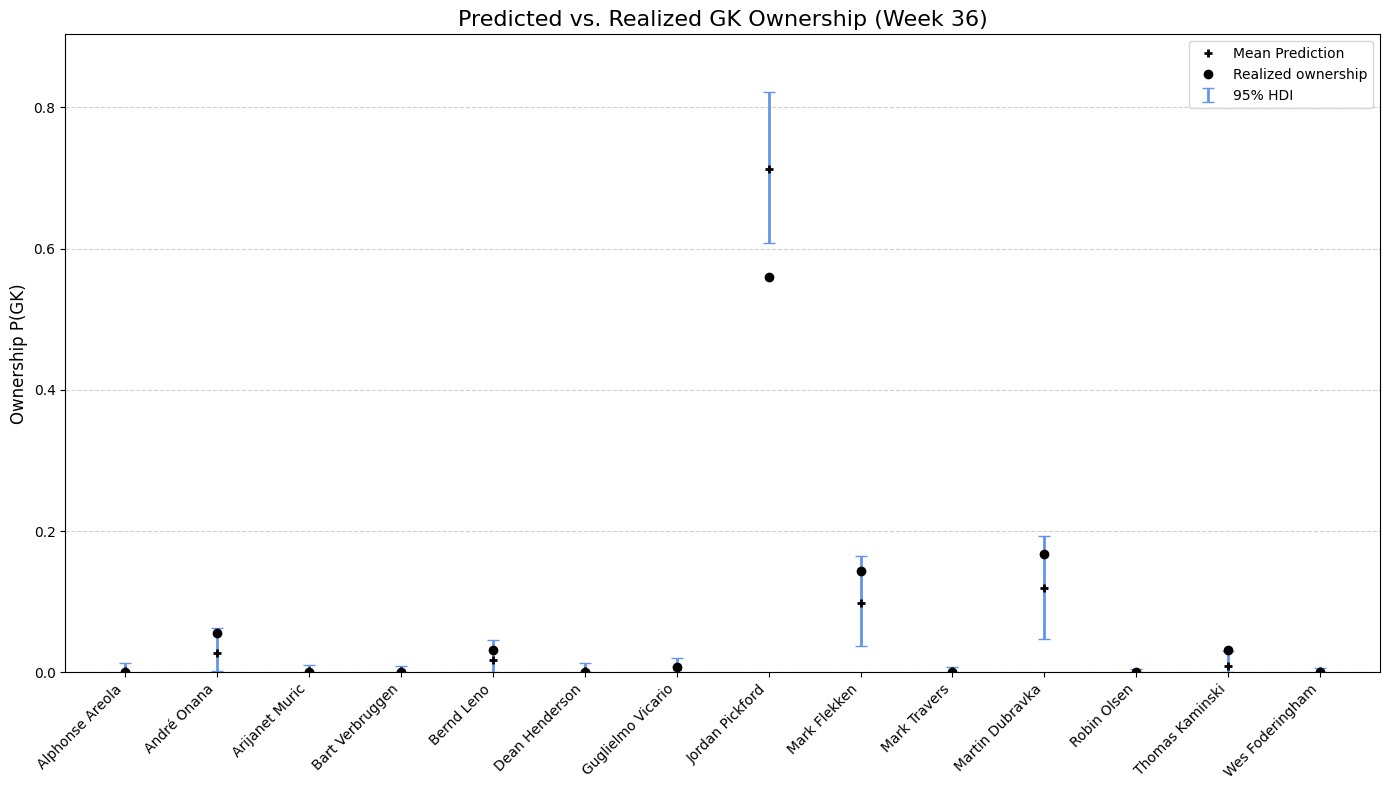

In [283]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_pca[0].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\1578748986.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


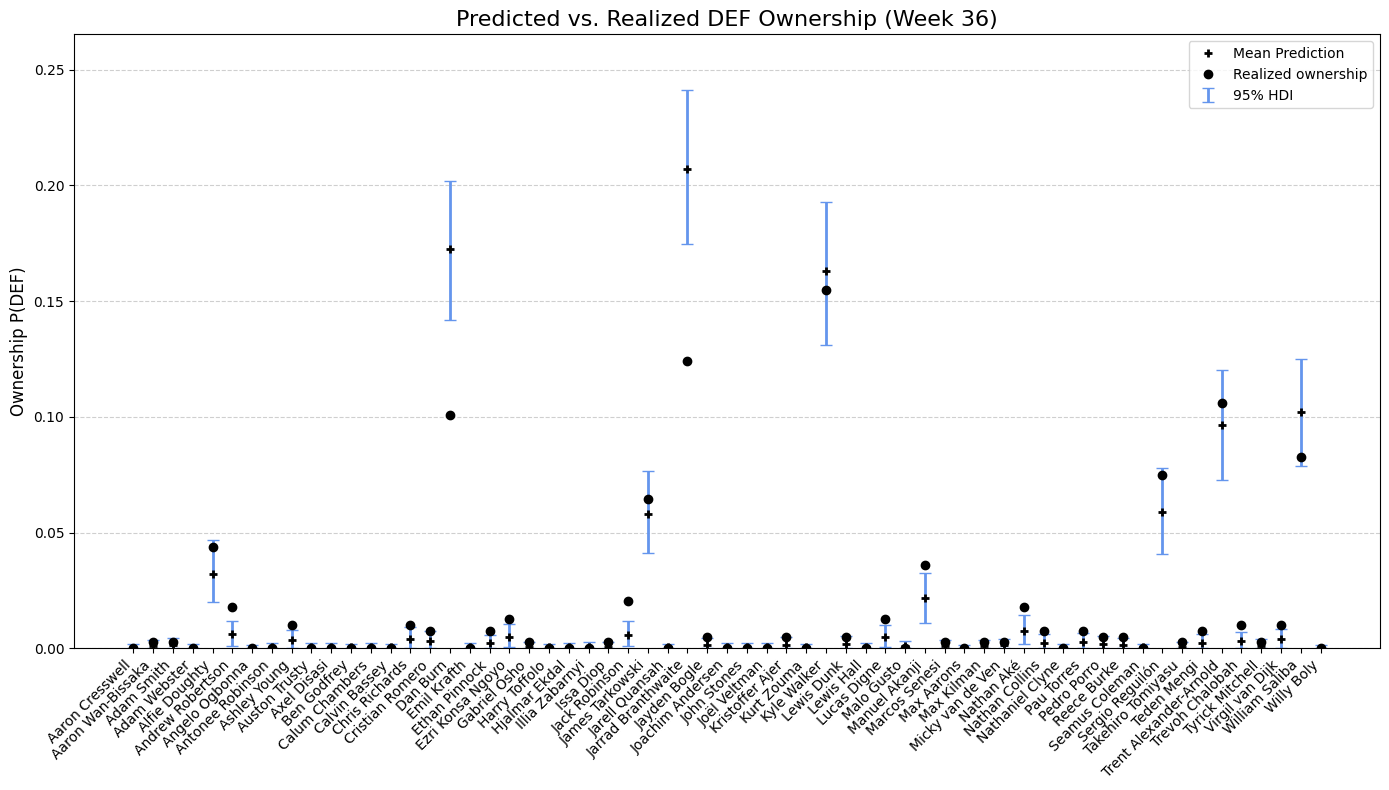

In [284]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_pca[1].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names,
    def_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\3798224499.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


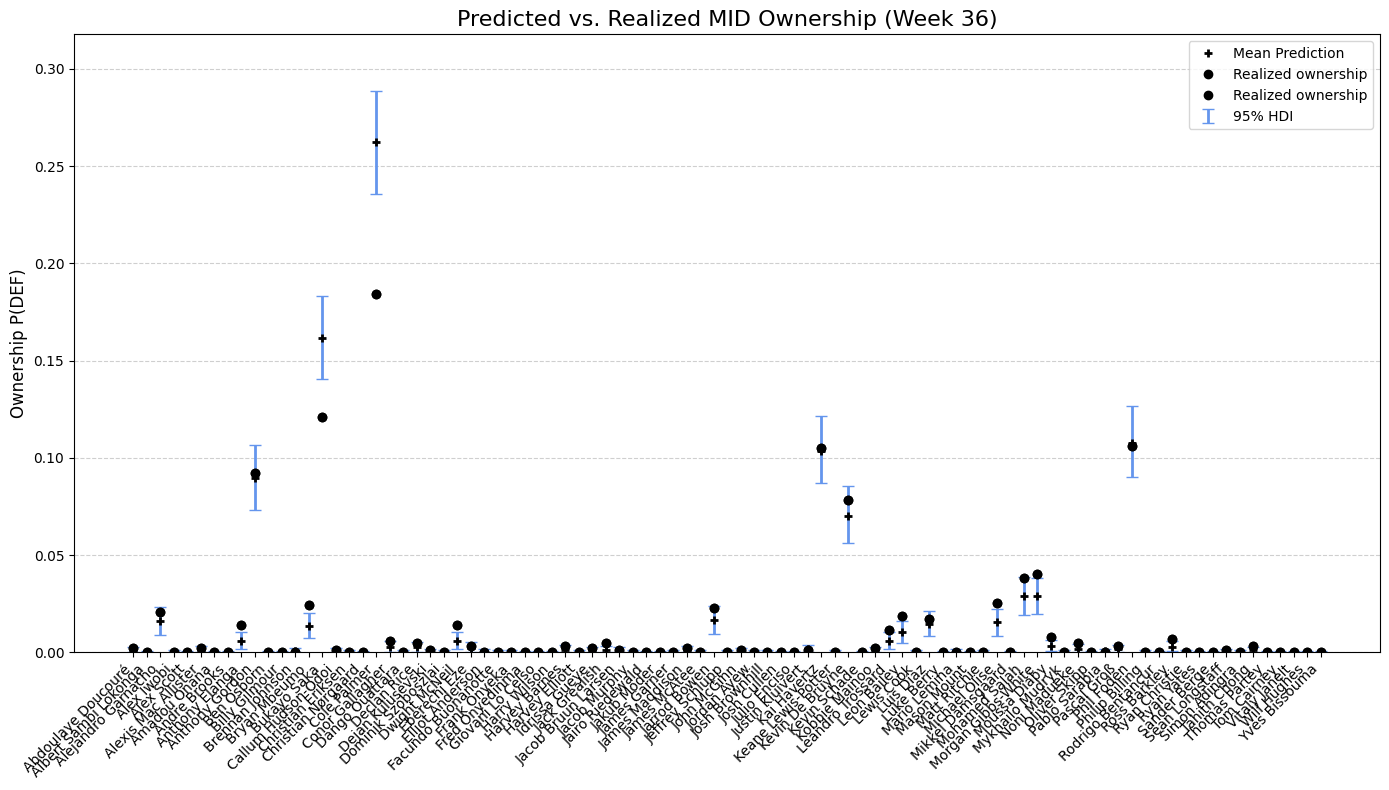

In [285]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_pca[2].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\2374748491.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


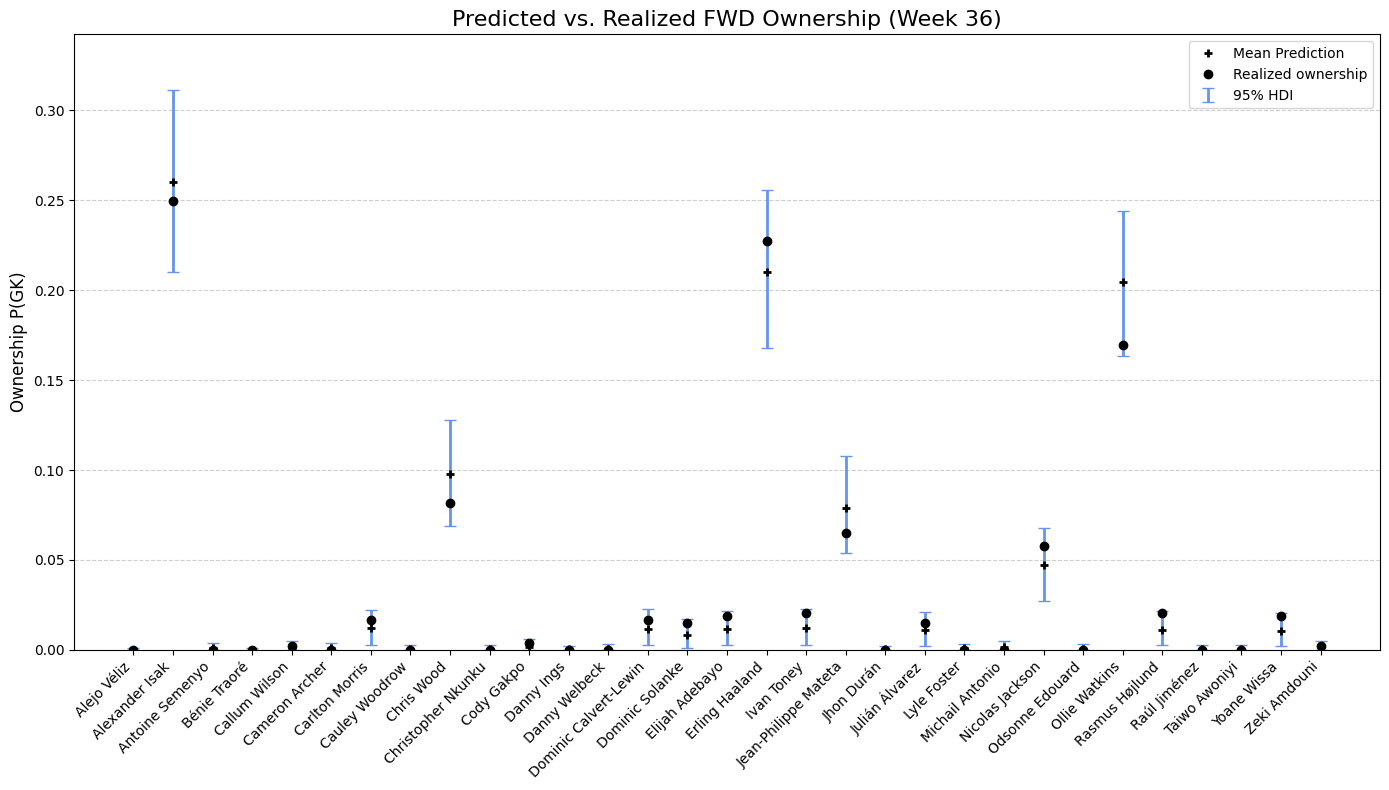

In [286]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_pca[3].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 36)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [287]:
generated_portfolios = sample_opponent_portfolios(
    O=200,
    batch_size = 2000,
    beta_estimates=all_beta_estimates,
    feature_matrices=X_pca,
    ids = ids,
    costs=prices,
    budget=100,
    teams=teams,
    xp_preds=xPts,
    p_vectors=p_vectors)


Generating 200 opponent portfolios...
⚙️ Using 4 cores to generate 200 teams...
✅ Collected 0 valid teams after 2000 attempts...: 3
✅ Collected 0 valid teams after 4000 attempts...: 6
✅ Collected 0 valid teams after 6000 attempts...: 7
✅ Collected 0 valid teams after 8000 attempts...: 9
✅ Collected 0 valid teams after 10000 attempts...: 10
✅ Collected 0 valid teams after 12000 attempts...: 11
✅ Collected 0 valid teams after 14000 attempts...: 12
✅ Collected 0 valid teams after 16000 attempts...: 13
✅ Collected 0 valid teams after 18000 attempts...: 14
✅ Collected 0 valid teams after 20000 attempts...: 16
✅ Collected 0 valid teams after 22000 attempts...: 18
✅ Collected 0 valid teams after 24000 attempts...: 18
✅ Collected 0 valid teams after 26000 attempts...: 21
✅ Collected 0 valid teams after 28000 attempts...: 23
✅ Collected 0 valid teams after 30000 attempts...: 26
✅ Collected 0 valid teams after 32000 attempts...: 27
✅ Collected 0 valid teams after 34000 attempts...: 28
✅ Collect

In [288]:
Wo_ = []
for i in generated_portfolios:
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in valid_player_ids])
    Wo_.append(squad)

Output()

Finished [100%]: Average Loss = 17,099
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.857,0.020,4.818,4.894,0.001,0.000,1049.0,820.0,NaN
delta[1],0.717,0.018,0.686,0.750,0.001,0.000,1108.0,1070.0,NaN
delta[2],5.835,0.022,5.795,5.880,0.001,0.001,920.0,1072.0,NaN
delta[3],5.092,0.020,5.057,5.134,0.001,0.000,907.0,875.0,NaN
delta[4],0.453,0.017,0.419,0.483,0.001,0.000,1000.0,908.0,NaN
...,...,...,...,...,...,...,...,...,...
G_r[195],53.267,0.081,53.114,53.414,0.003,0.002,800.0,681.0,NaN
G_r[196],51.437,0.080,51.272,51.575,0.003,0.002,960.0,912.0,NaN
G_r[197],48.597,0.079,48.442,48.742,0.003,0.002,965.0,1071.0,NaN
G_r[198],51.240,0.074,51.092,51.372,0.002,0.002,955.0,873.0,NaN


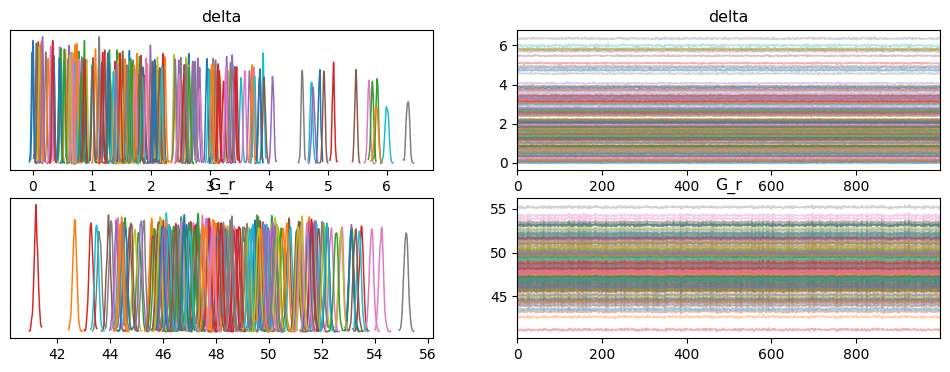

In [289]:
def make_positive_definite(cov_mat, epsilon=1e-6):
    # Ensure symmetry
    cov_mat = (cov_mat + cov_mat.T) / 2

    # Add jitter to diagonal
    jitter = epsilon * np.eye(cov_mat.shape[0])
    return cov_mat + jitter


def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
    num_player = len(Wo_[0])

    cov_mat = make_positive_definite(cov_mat)

    with pm.Model() as model:
        L = np.linalg.cholesky(make_positive_definite(cov_mat))
        delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)
        # delta = pm.MvNormal("delta", mu=mu_delta, cov=cov_mat, shape=num_player)

        # Compute 90th percentile of performance
        dot_product = pt.dot(Wo_, delta)
        G_r = pm.Deterministic("G_r",  np.percentile(dot_product, 90)) # pt.sort(dot_product)[-int(len(Wo_) * 0.9)])

        approx = pm.fit(method='advi', n=20000)

        trace = approx.sample(1000)
        # trace = pm.sample(
        #     3000,
        #     return_inferencedata=True,
        #     cores=2,
        #     chains=10,
        #     progressbar=True,
        #     target_accept=0.95
        # )

        # G_r_90 = np.percentile(pt.dot(trace.posterior['delta'].values, Wo_), 90)

    return trace
MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta)

az.plot_trace(MC_sim_trace, var_names=["delta", "G_r"])
az.summary(MC_sim_trace, var_names=["delta", "G_r"])

In [290]:
delta_samples = MC_sim_trace.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
G_r_samples   = MC_sim_trace.posterior['G_r'].stack(sample=("chain", "draw")).values.T    # shape (N_samples, 200)

G_r_scalar = np.percentile(G_r_samples, 90, axis=1)  # shape (N_samples,)
print(G_r_scalar.shape, delta_samples.shape)

mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G = generate_cov_delta(delta_samples, G_r_scalar)


(1000,) (1000, 195)
(1000, 195) (1000,)


In [291]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda, best_w, best_prob = optimize_portfolio(W_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_scalar, players_preds)
print(f"Best λ: {best_lambda}, Best Probability of Outperforming: {best_prob}")


selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, fg_managers_36)
selected, player_names, total_points

195 195
195 195 {'Fulham', 'Brighton and Hove Albion', 'Sheffield United', 'Crystal Palace', 'Newcastle United', 'Nottingham Forest', 'Manchester United', 'Arsenal', 'Manchester City', 'Liverpool', 'Bournemouth', 'Luton', 'Tottenham Hotspur', 'Everton', 'Chelsea', 'West Ham United', 'Burnley', 'Aston Villa', 'Brentford', 'Wolverhampton Wanderers'}
Fulham [22, 30, 39, 77, 83, 164, 182] 7 195
Brighton and Hove Albion [4, 27, 31, 55, 70, 90, 109, 110, 124, 158, 175] 11 195
Sheffield United [15, 25, 29, 35, 86, 98, 188] 7 195
Crystal Palace [43, 56, 63, 89, 99, 100, 102, 105, 141, 151, 154, 185, 189] 13 195
Newcastle United [10, 20, 37, 52, 65, 66, 78, 88, 125, 136, 138, 173] 12 195
Nottingham Forest [19, 32, 36, 44, 76, 146, 170, 177, 191] 9 195
Manchester United [1, 6, 17, 45, 117, 137, 163, 174] 8 195
Arsenal [34, 57, 113, 121, 178, 181, 190] 7 195
Manchester City [49, 67, 85, 93, 104, 111, 115, 120, 131, 149, 161] 11 195
Liverpool [11, 16, 48, 61, 79, 95, 127, 145, 183, 186] 10 195
Bou

([19, 20, 60, 263, 308, 313, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Virgil van Dijk',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 102.0)

In [292]:
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, fg_managers_36)
selected, player_names, total_points

[15.  8. 42.  3.  5.  2. 13.  2.  5.  1.  6.] ---------> [8.42857821 5.75904691 9.66969921 2.348      2.83085205 5.88199999
 4.82644648 2.12951213 3.48122268 1.42490824 5.19414667]
Your predicted player’s total of 102.0 points would rank:
→ Position: 32 out of 229 managers
→ Percentile: Top 86.03%

Closest scores around you:
   points    prize
0   103.5  R 22.39
1   102.5  R 22.39
2   102.0  R 22.39
3   102.0  R 22.39
4   102.0  R 22.39


([19, 20, 60, 263, 308, 313, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Virgil van Dijk',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 102.0)

# GW 37


In [293]:
players_preds = pd.read_csv(f'../FPL predictors/Fantasy Go/fantasyGo_preds_37.csv', index_col=0)
# Check if teams match
players_preds = players_preds[players_preds['player_team'].isin(FPL_teams_23_24)]

players_preds['xP_cost'] = round(players_preds['xP']/players_preds['value'], 2)

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)
data_23_24_37 = data_23_24[data_23_24['event'] < 36]

# # Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')

## Generate Cov_Mat


In [294]:
mu_delta, sigma_delta, cov_mat, valid_player_ids = generate_cov_mat(players_preds, data_23_24_37)
# cov_mat
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)]

Starting to optimize team selection...
(204, 189)
(5058, 180)
(204,) (204,) (204, 204)


## Data Preparations


In [295]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_37 = data_23_24_37[data_23_24_37['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
data, prices, xPts, positions , teams, ids, X_pca = clean_data(players_preds, valid_player_ids)

starting to clean data...
data successfully cleaned...


In [296]:
ownership_gk = players_preds[players_preds['position'] == 'GK']['ownership_percent']
gk_names = players_preds[players_preds['position'] == 'GK']['FPL_Name']
gk_probs_obs = ownership_gk / ownership_gk.sum()

ownership_def = players_preds[players_preds['position'] == 'DEF']['ownership_percent']
def_names = players_preds[players_preds['position'] == 'DEF']['FPL_Name']
def_probs_obs = ownership_def / ownership_def.sum()

cols = data_cols.copy()
cols.append('ownership_percent')
cols.append('FPL_Name')

# mids = players_preds[players_preds['position'] == 'MID'][cols].dropna()
# ownership_mid = mids['ownership_percent']
# mid_names = mids['FPL_Name']
# mid_probs_obs = ownership_mid / ownership_mid.sum()

ownership_mid = players_preds[players_preds['position'] == 'MID']['ownership_percent']
mid_names = players_preds[players_preds['position'] == 'MID']['FPL_Name']
mid_probs_obs = ownership_mid / ownership_mid.sum()


cols = feats_cols_fwd.copy()
cols.append('FPL_Name')
fwds = players_preds[players_preds['position'] == 'FWD'][cols].dropna()
ownership_fwds = fwds['ownership_percent']
fwd_names = fwds['FPL_Name']
fwd_probs_obs = ownership_fwds / ownership_fwds.sum()

In [297]:
print(X_pca[0].shape, X_pca[1].shape, X_pca[2].shape)
print(beta_gk.shape, beta_def.shape, beta_mid.shape)

(14, 12) (66, 13) (93, 11)
(12000, 12) (12000, 13) (12000, 11)


In [298]:
alphas = {
        'GK': np.exp(X_pca[0] @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_pca[1] @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_pca[2] @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_pca[3] @ beta_fwd.T).mean(axis=1)
    }


p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}
p_vectors

{'GK': array([4.31281860e-02, 8.10981000e-02, 2.22770443e-02, 3.73466018e-06,
        2.69240961e-04, 5.65661920e-04, 1.12726784e-05, 1.83464371e-01,
        5.92210959e-01, 6.02797762e-03, 8.69223305e-04, 6.98321325e-02,
        7.73326671e-05, 1.64763897e-04]),
 'DEF': array([5.54119597e-04, 3.33390332e-04, 1.62047880e-04, 2.84935334e-05,
        1.13194869e-03, 5.95434233e-13, 2.73250063e-03, 2.47202082e-03,
        2.26324192e-05, 4.78746110e-05, 1.81647797e-04, 2.31318641e-06,
        1.76249772e-02, 1.16557943e-01, 3.13913767e-01, 4.26977652e-04,
        2.59482025e-03, 3.16569141e-06, 6.03409570e-05, 5.88425019e-06,
        2.26806262e-04, 8.18831715e-05, 6.07553883e-07, 1.30659587e-04,
        8.93668805e-03, 2.51626539e-03, 9.69928329e-02, 6.82180878e-04,
        2.70622696e-04, 7.48891567e-06, 3.36874578e-04, 1.64721247e-03,
        4.86480296e-08, 7.86356165e-03, 3.21546443e-02, 6.55211207e-03,
        4.49374116e-03, 1.47960615e-05, 1.06263053e-03, 1.70299882e-03,
        9

## Plots


### GK


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\4096672833.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


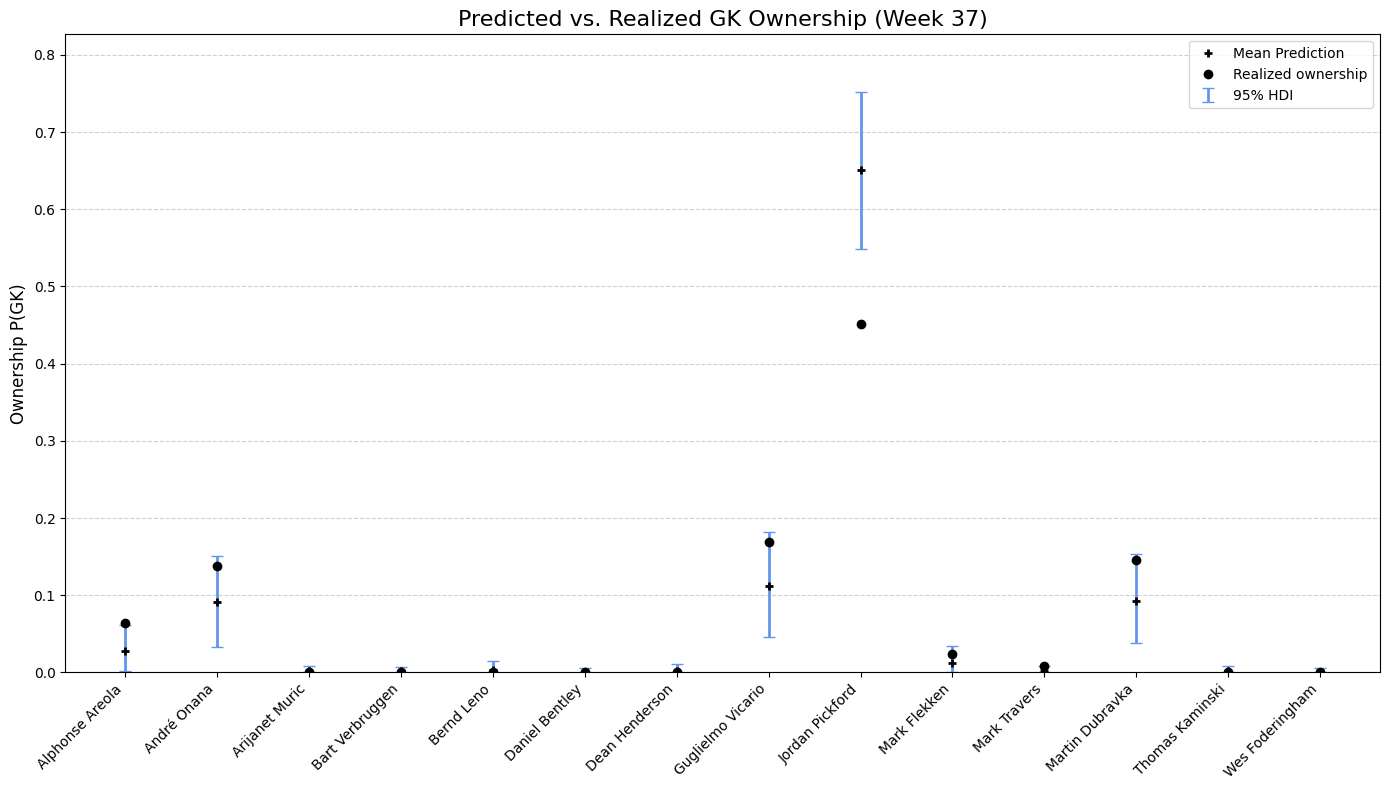

In [299]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_pca[0].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\2654067066.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


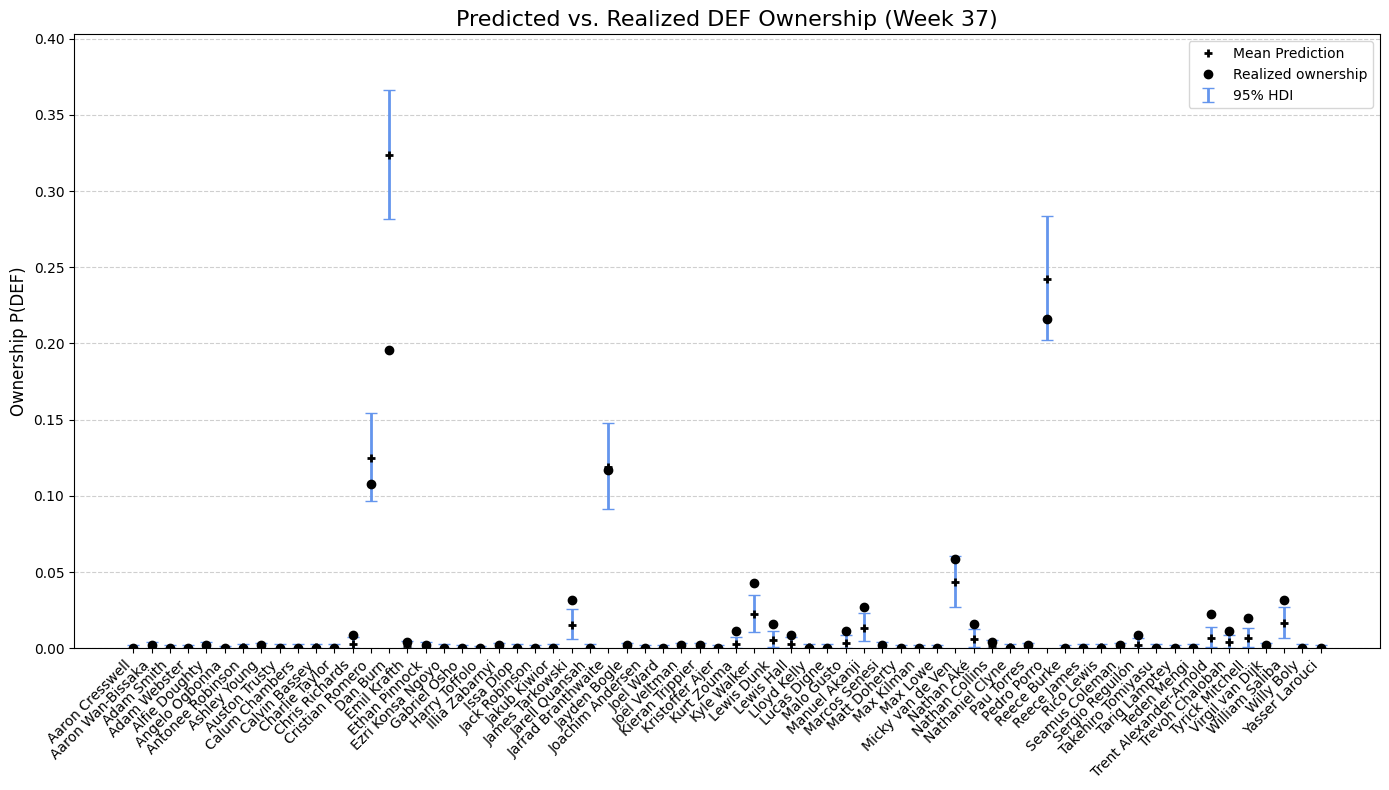

In [300]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_pca[1].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names,
    def_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\3360249588.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


(93,) 93


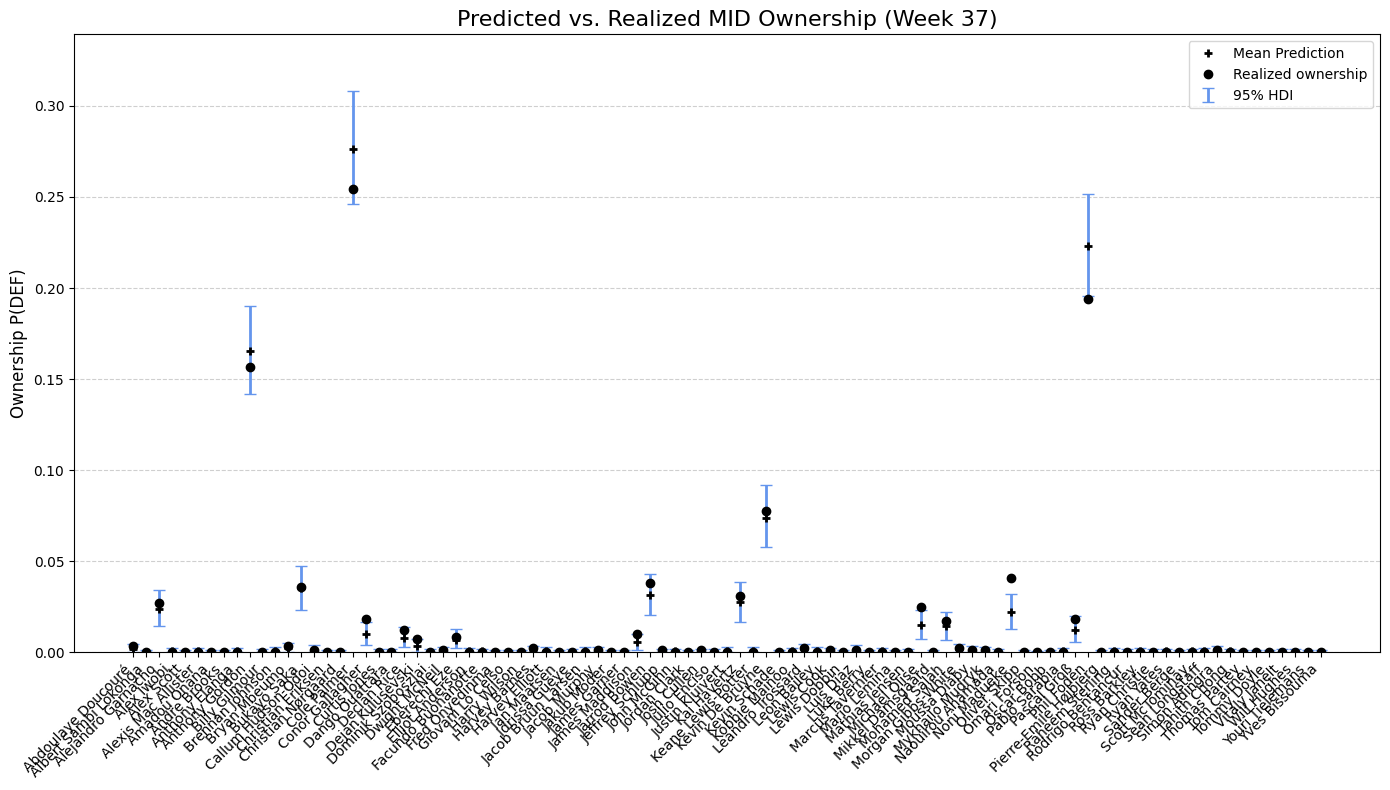

In [301]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_pca[2].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

print(mid_names.shape, len(hdi_midpoint))

# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\4259362983.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


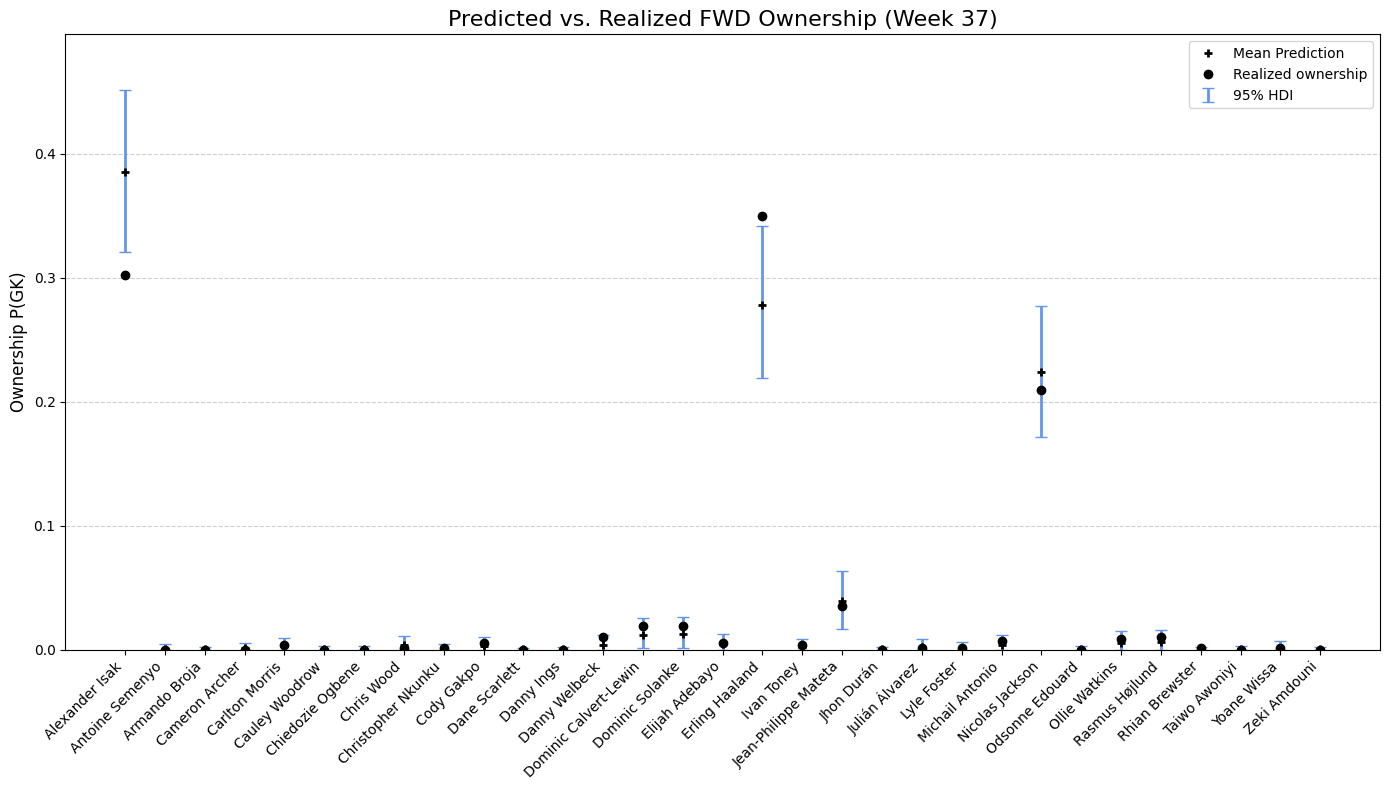

In [302]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_pca[3].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 37)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [303]:
generated_portfolios = sample_opponent_portfolios(
    O=200,
    batch_size = 2000,
    beta_estimates=all_beta_estimates,
    feature_matrices=X_pca,
    ids = ids,
    costs=prices,
    budget=100,
    teams=teams,
    xp_preds=xPts,
    p_vectors=p_vectors)


Generating 200 opponent portfolios...
⚙️ Using 4 cores to generate 200 teams...
✅ Collected 0 valid teams after 2000 attempts...: 0
✅ Collected 0 valid teams after 4000 attempts...: 1
✅ Collected 0 valid teams after 6000 attempts...: 1
✅ Collected 0 valid teams after 8000 attempts...: 1
✅ Collected 0 valid teams after 10000 attempts...: 1
✅ Collected 0 valid teams after 12000 attempts...: 1
✅ Collected 0 valid teams after 14000 attempts...: 1
✅ Collected 0 valid teams after 16000 attempts...: 1
✅ Collected 0 valid teams after 18000 attempts...: 1
✅ Collected 0 valid teams after 20000 attempts...: 1
✅ Collected 0 valid teams after 22000 attempts...: 1
✅ Collected 0 valid teams after 24000 attempts...: 2
✅ Collected 0 valid teams after 26000 attempts...: 2
✅ Collected 0 valid teams after 28000 attempts...: 2
✅ Collected 0 valid teams after 30000 attempts...: 2
✅ Collected 0 valid teams after 32000 attempts...: 2
✅ Collected 0 valid teams after 34000 attempts...: 2
✅ Collected 0 valid te

In [304]:
Wo_ = []
for i in generated_portfolios:
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in valid_player_ids])
    Wo_.append(squad)

Output()

Finished [100%]: Average Loss = 17,810
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.853,0.021,4.814,4.894,0.001,0.000,1026.0,983.0,NaN
delta[1],1.664,0.021,1.627,1.704,0.001,0.000,896.0,942.0,NaN
delta[2],0.731,0.018,0.700,0.767,0.001,0.000,1028.0,941.0,NaN
delta[3],5.837,0.022,5.793,5.877,0.001,0.000,1086.0,984.0,NaN
delta[4],5.099,0.019,5.065,5.134,0.001,0.000,1053.0,1021.0,NaN
...,...,...,...,...,...,...,...,...,...
G_r[195],47.231,0.076,47.086,47.358,0.002,0.002,993.0,1020.0,NaN
G_r[196],42.505,0.071,42.376,42.643,0.002,0.002,854.0,914.0,NaN
G_r[197],50.053,0.074,49.907,50.181,0.002,0.002,1013.0,835.0,NaN
G_r[198],46.430,0.077,46.294,46.583,0.002,0.002,963.0,872.0,NaN


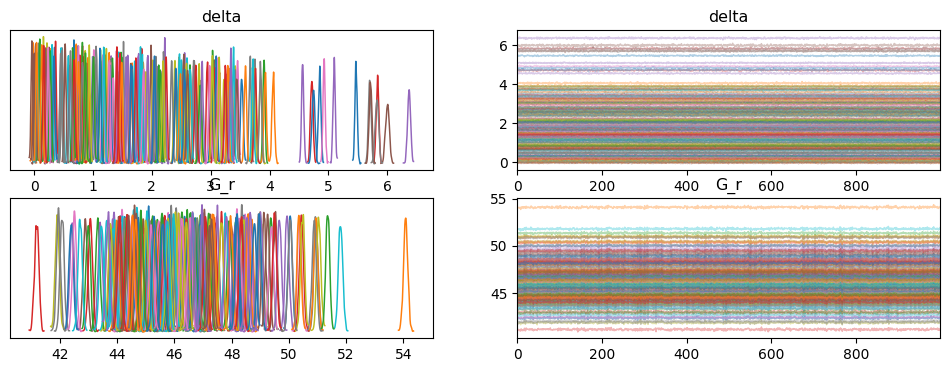

In [305]:
def make_positive_definite(cov_mat, epsilon=1e-6):
    # Ensure symmetry
    cov_mat = (cov_mat + cov_mat.T) / 2

    # Add jitter to diagonal
    jitter = epsilon * np.eye(cov_mat.shape[0])
    return cov_mat + jitter


def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
    num_player = len(Wo_[0])

    cov_mat = make_positive_definite(cov_mat)

    with pm.Model() as model:
        L = np.linalg.cholesky(make_positive_definite(cov_mat))
        delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)
        # delta = pm.MvNormal("delta", mu=mu_delta, cov=cov_mat, shape=num_player)

        # Compute 90th percentile of performance
        dot_product = pt.dot(Wo_, delta)
        G_r = pm.Deterministic("G_r",  np.percentile(dot_product, 90)) # pt.sort(dot_product)[-int(len(Wo_) * 0.9)])

        approx = pm.fit(method='advi', n=20000)

        trace = approx.sample(1000)
        # trace = pm.sample(
        #     3000,
        #     return_inferencedata=True,
        #     cores=2,
        #     chains=10,
        #     progressbar=True,
        #     target_accept=0.95
        # )

        # G_r_90 = np.percentile(pt.dot(trace.posterior['delta'].values, Wo_), 90)

    return trace
MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta)

az.plot_trace(MC_sim_trace, var_names=["delta", "G_r"])
az.summary(MC_sim_trace, var_names=["delta", "G_r"])

In [306]:
delta_samples = MC_sim_trace.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
G_r_samples   = MC_sim_trace.posterior['G_r'].stack(sample=("chain", "draw")).values.T    # shape (N_samples, 200)

G_r_scalar = np.percentile(G_r_samples, 90, axis=1)  # shape (N_samples,)
print(G_r_scalar.shape, delta_samples.shape)

mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G = generate_cov_delta(delta_samples, G_r_scalar)


(1000,) (1000, 204)
(1000, 204) (1000,)


In [307]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda, best_w, best_prob = optimize_portfolio(W_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_scalar, players_preds)
print(f"Best λ: {best_lambda}, Best Probability of Outperforming: {best_prob}")
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, fg_managers_37)
selected, player_names, total_points

204 204
204 204 {'Fulham', 'Brighton and Hove Albion', 'Sheffield United', 'Crystal Palace', 'Newcastle United', 'Nottingham Forest', 'Manchester United', 'Arsenal', 'Manchester City', 'Liverpool', 'Bournemouth', 'Luton', 'Tottenham Hotspur', 'Everton', 'Chelsea', 'West Ham United', 'Burnley', 'Aston Villa', 'Brentford', 'Wolverhampton Wanderers'}
Fulham [20, 26, 33, 75, 81, 188] 6 204
Brighton and Hove Albion [4, 25, 27, 54, 69, 87, 104, 105, 121, 160, 180, 184] 12 204
Sheffield United [14, 24, 83, 94, 139, 169, 195, 199] 8 204
Crystal Palace [39, 55, 62, 95, 96, 98, 99, 140, 148, 151, 154, 192, 196] 13 204
Newcastle United [9, 18, 49, 64, 65, 76, 85, 112, 122, 135, 178] 11 204
Nottingham Forest [17, 28, 31, 40, 74, 145, 174, 182, 198] 9 204
Manchester United [1, 6, 15, 41, 113, 157, 166, 176, 179] 9 204
Arsenal [30, 56, 86, 108, 117, 183, 187, 197] 8 204
Manchester City [45, 66, 106, 110, 116, 129, 149, 158, 163, 170] 10 204
Liverpool [10, 44, 48, 60, 77, 91, 125, 144, 190, 193] 10 2

([19, 20, 60, 263, 308, 313, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Virgil van Dijk',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 65.0)

In [308]:
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, fg_managers_37)
selected, player_names, total_points

[ 3.  6.  2.  8.  5.  6.  2.  5. 18.  1.  9.] ---------> [4.00510161 3.41600723 3.20246962 1.906      2.76811747 1.80099999
 2.90345529 3.5959465  4.91468495 1.21157122 0.58862385]
Your predicted player’s total of 65.0 points would rank:
→ Position: 238 out of 243 managers
→ Percentile: Top 2.06%

Closest scores around you:
   points prize
0    69.5   NaN
1    67.0   NaN
2    63.5   NaN
3    60.0   NaN
4    57.5   NaN


([19, 20, 60, 263, 308, 313, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Virgil van Dijk',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 65.0)

# GW 38


In [309]:
players_preds = pd.read_csv(f'../FPL predictors/Fantasy Go/fantasyGo_preds_38.csv', index_col=0)
# Check if teams match
players_preds = players_preds[players_preds['player_team'].isin(FPL_teams_23_24)]

players_preds['xP_cost'] = round(players_preds['xP']/players_preds['value'], 2)

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)
data_23_24_38 = data_23_24[data_23_24['event'] < 36]

# # Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')

## Generate Cov_Mat


In [310]:
mu_delta, sigma_delta, cov_mat, valid_player_ids = generate_cov_mat(players_preds, data_23_24_38)
# cov_mat
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)]

Starting to optimize team selection...
(196, 189)
(4866, 180)
(195,) (195,) (195, 195)


## Data Preparations


In [311]:
data_cols.append('fpl_id')
data_cols_gk.append('fpl_id')

data_23_24_38 = data_23_24_38[data_23_24_38['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
players_preds = players_preds[players_preds['fpl_id'].isin(valid_player_ids)].reset_index(drop=True)
data, prices, xPts, positions , teams, ids, X_pca = clean_data(players_preds, valid_player_ids)

starting to clean data...
data successfully cleaned...


In [312]:
ownership_gk = players_preds[players_preds['position'] == 'GK']['ownership_percent']
gk_names = players_preds[players_preds['position'] == 'GK']['FPL_Name']
gk_probs_obs = ownership_gk / ownership_gk.sum()

ownership_def = players_preds[players_preds['position'] == 'DEF']['ownership_percent']
def_names = players_preds[players_preds['position'] == 'DEF']['FPL_Name']
def_probs_obs = ownership_def / ownership_def.sum()

cols = data_cols.copy()
cols.append('ownership_percent')
cols.append('FPL_Name')

# mids = players_preds[players_preds['position'] == 'MID'][cols].dropna()
# ownership_mid = mids['ownership_percent']
# mid_names = mids['FPL_Name']
# mid_probs_obs = ownership_mid / ownership_mid.sum()

ownership_mid = players_preds[players_preds['position'] == 'MID']['ownership_percent']
mid_names = players_preds[players_preds['position'] == 'MID']['FPL_Name']
mid_probs_obs = ownership_mid / ownership_mid.sum()


cols = feats_cols_fwd.copy()
cols.append('FPL_Name')
fwds = players_preds[players_preds['position'] == 'FWD'][cols].dropna()
ownership_fwds = fwds['ownership_percent']
fwd_names = fwds['FPL_Name']
fwd_probs_obs = ownership_fwds / ownership_fwds.sum()

In [313]:
print(X_pca[0].shape, X_pca[1].shape, X_pca[2].shape)
print(beta_gk.shape, beta_def.shape, beta_mid.shape)

(14, 12) (61, 13) (89, 11)
(12000, 12) (12000, 13) (12000, 11)


In [314]:
alphas = {
        'GK': np.exp(X_pca[0] @ beta_gk.T).mean(axis=1),
        'DEF': np.exp(X_pca[1] @ beta_def.T).mean(axis=1),
        'MID': np.exp(X_pca[2] @ beta_mid.T).mean(axis=1),
        'FWD': np.exp(X_pca[3] @ beta_fwd.T).mean(axis=1)
    }


p_vectors = {pos: np.random.dirichlet(alpha) for pos, alpha in alphas.items()}
p_vectors

{'GK': array([6.03445760e-08, 6.98279416e-02, 4.65996412e-04, 1.28161330e-06,
        1.04145554e-02, 1.05846827e-03, 3.66883293e-03, 6.82311080e-01,
        4.26744479e-02, 1.13589053e-03, 1.56967463e-01, 1.22338791e-03,
        3.02505946e-02, 9.29085714e-16]),
 'DEF': array([3.30712402e-05, 1.01894239e-03, 1.08873253e-03, 3.44235724e-05,
        2.21978089e-02, 2.94428973e-03, 5.18312922e-04, 9.17282561e-04,
        1.85262528e-03, 2.32708692e-03, 2.86927960e-06, 2.87978642e-05,
        4.13289962e-04, 6.67850689e-06, 4.33147189e-03, 3.77951979e-03,
        1.72551212e-01, 1.61402737e-04, 3.44594698e-03, 6.22978236e-03,
        2.32080257e-04, 1.23634831e-09, 1.49815358e-04, 8.62606042e-04,
        7.07377041e-04, 8.98883229e-03, 5.92857339e-02, 4.35297157e-07,
        2.13826784e-01, 4.21911796e-03, 1.21770040e-04, 1.24226359e-04,
        4.56685170e-05, 1.55290116e-03, 1.59809394e-03, 1.72583344e-01,
        7.25895309e-04, 2.03790059e-04, 1.16538692e-02, 1.85336297e-04,
        1

## Plots


### GK


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\1823924027.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


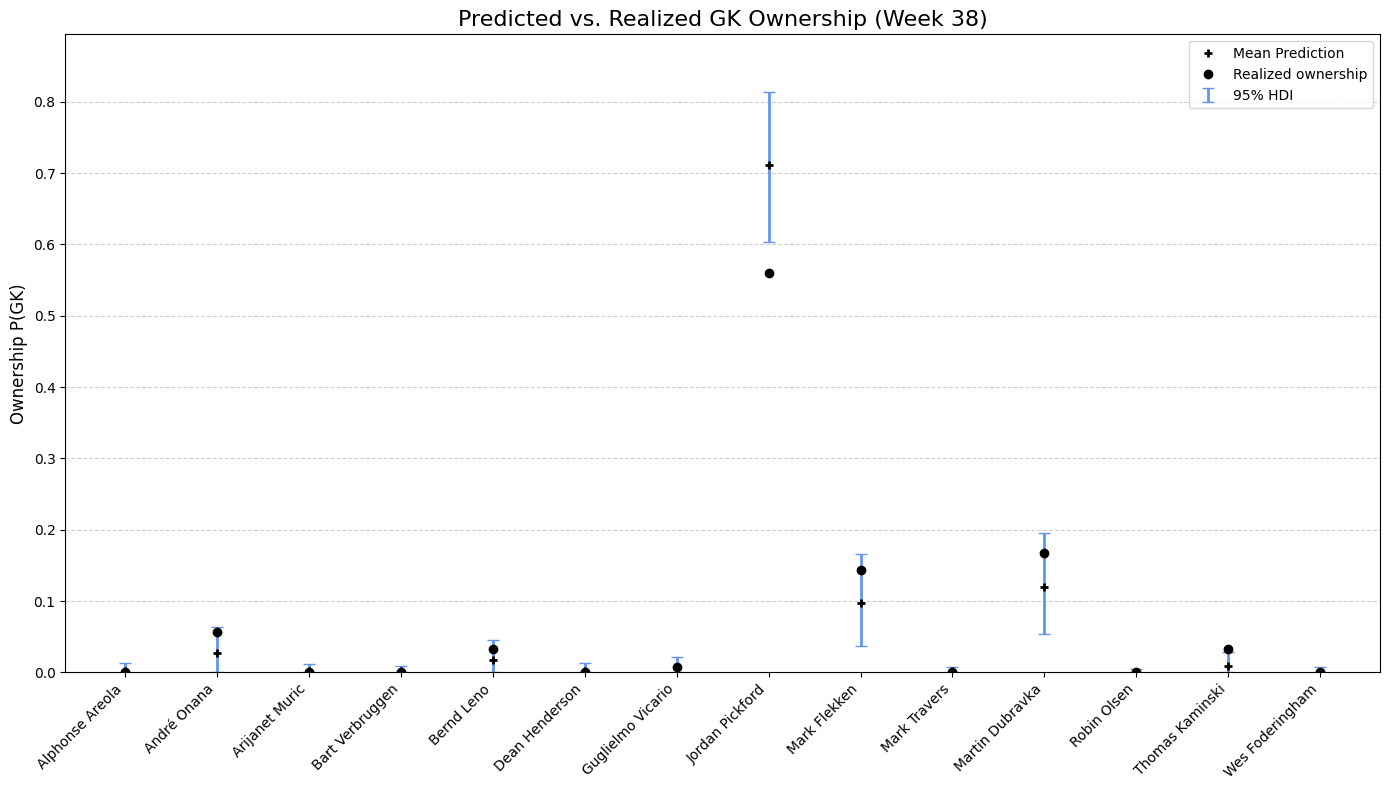

In [315]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_gk.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_gk_features = X_pca[0].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_gk[i]

    eta_vector = np.dot(X_gk_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=gk_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    gk_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    gk_names,
    gk_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized GK Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(gk_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### DEF


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\1461560486.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


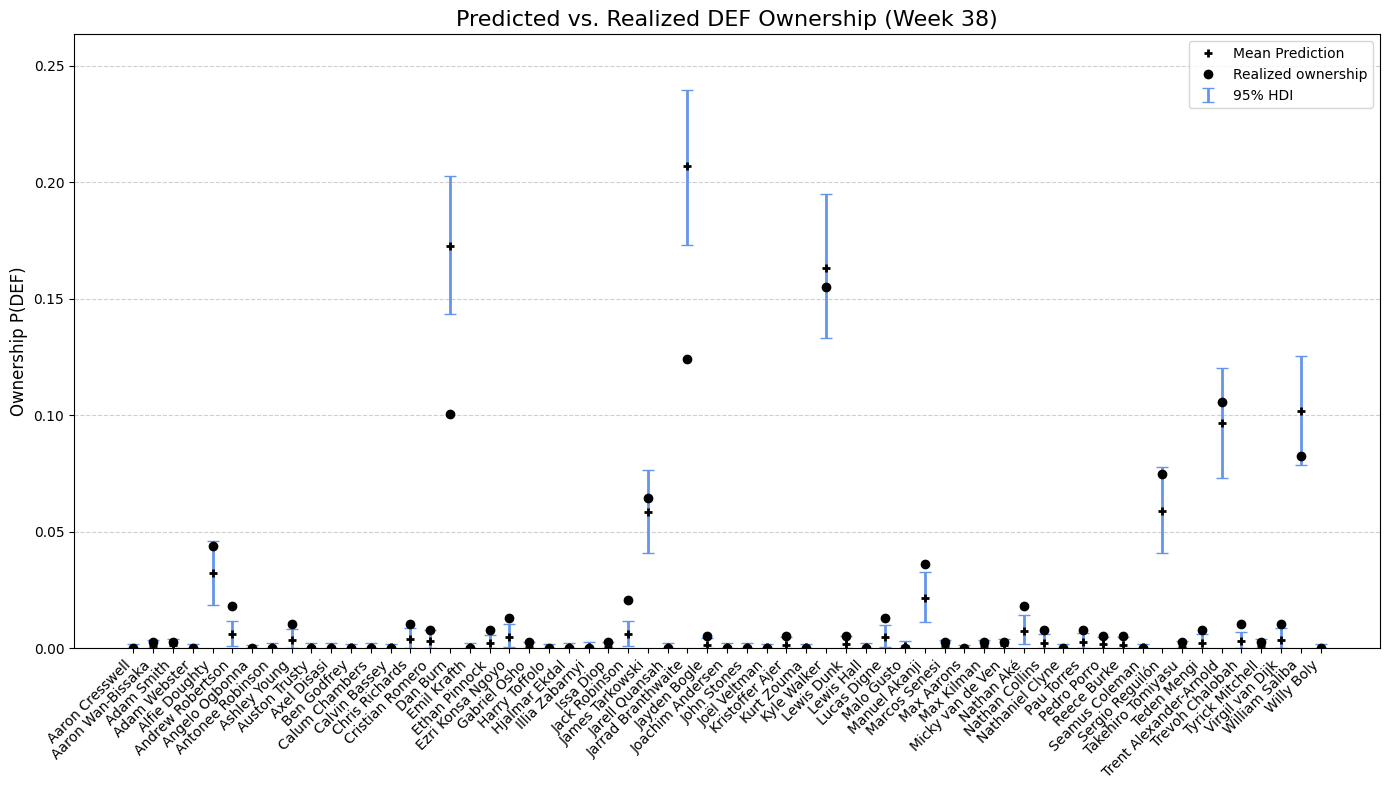

In [316]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_def.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_def_features = X_pca[1].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_def[i]

    eta_vector = np.dot(X_def_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=def_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    def_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    def_names,
    def_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized DEF Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(def_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### MID


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\3562037642.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


(89,) 89


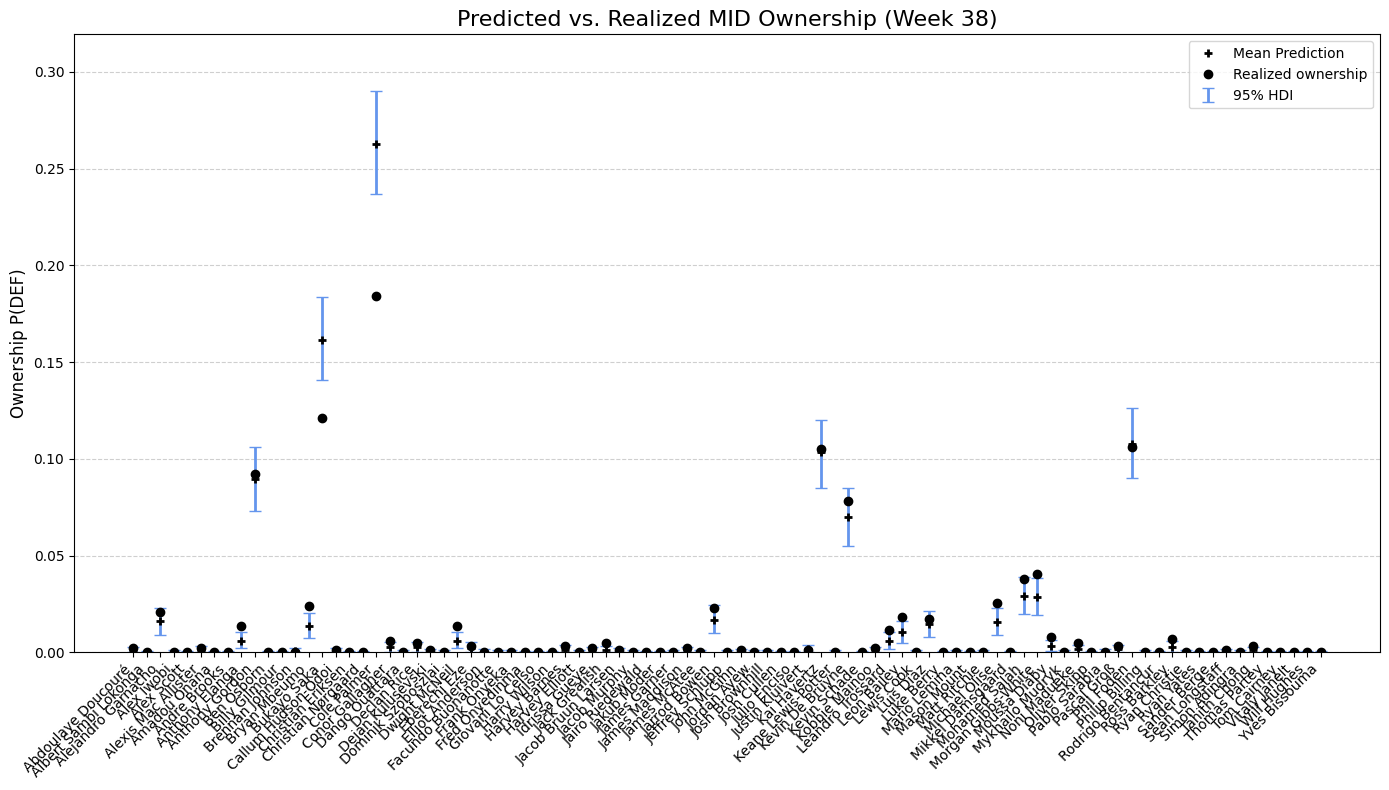

In [317]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_mid.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_mid_features = X_pca[2].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_mid[i]

    eta_vector = np.dot(X_mid_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_midpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))

print(mid_names.shape, len(hdi_midpoint))

# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=mid_names,
    y=hdi_midpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    mid_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    mid_names,
    mid_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized MID Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(DEF)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### FWD


Extracted 12000 posterior samples for beta.


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_7896\45277678.py:30: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_results = az.hdi(predictions_array, hdi_prob=0.95)


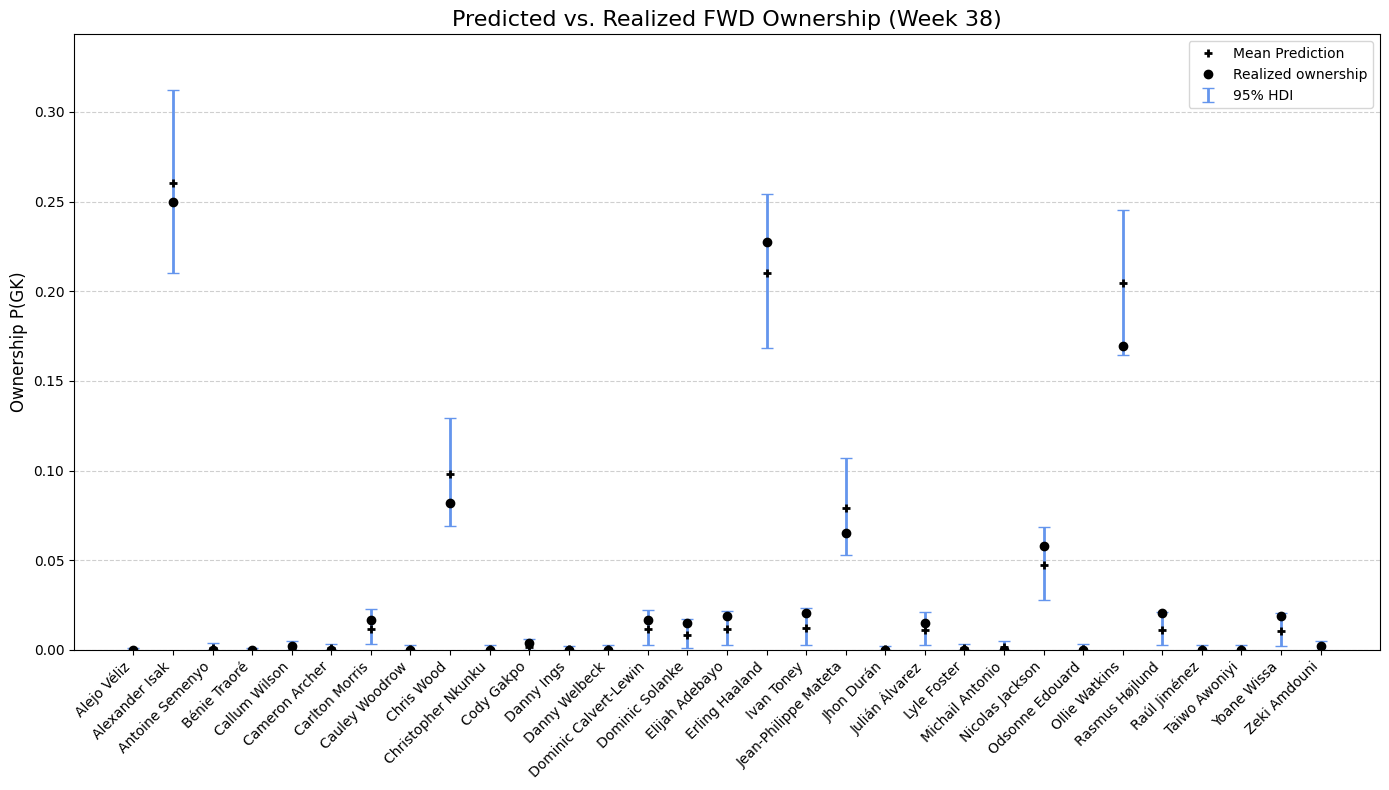

In [318]:
# Get all posterior samples for the 'betas' variable from the trace
num_samples = beta_fwd.shape[0]
print(f"Extracted {num_samples} posterior samples for beta.")


X_fwd_features = X_pca[3].values  # <-- Use .values to get the numpy array


# --- 3. Generate a Prediction for Each Sample ---
# For each of the 2000 beta samples, we generate one possible ownership vector
all_predictions = []
epsilon = 1e-6 # For numerical stability

for i in range(num_samples):
    beta_sample = beta_fwd[i]

    eta_vector = np.dot(X_fwd_features, beta_sample)
    alpha_sample = np.exp(eta_vector) + epsilon

    prediction = np.random.dirichlet(alpha_sample)
    all_predictions.append(prediction)

# Convert list of predictions into a numpy array (samples x num_players)
predictions_array = np.array(all_predictions)

# --- 4. Calculate Intervals and Means ---
mean_preds = np.mean(predictions_array, axis=0)

# Calculate the 95% HDI
hdi_results = az.hdi(predictions_array, hdi_prob=0.95)
lower_bounds = hdi_results[:, 0]
upper_bounds = hdi_results[:, 1]

# --- FIX 2: Center the error bar on its *own* midpoint ---
hdi_fwdpoint = (lower_bounds + upper_bounds) / 2
# Calculate the error length from the midpoint (always positive)
hdi_half_width = (upper_bounds - lower_bounds) / 2
y_err = hdi_half_width  # This is the new, safe y_err

# --- 5. Plot the Results ---
plt.figure(figsize=(14, 8))


# Plot the 95% Prediction Intervals as blue error bars
# Plot the 95% HDI (centered on its midpoint)
plt.errorbar(
    x=fwd_names,
    y=hdi_fwdpoint,   # <-- Use the HDI midpoint as the center
    yerr=y_err,       # <-- Use the symmetric half-width
    fmt='none',
    ecolor='cornflowerblue',
    elinewidth=2,
    capsize=4,
    label='95% HDI'   # <-- Corrected label
)

# Plot the Mean Prediction as a separate marker
plt.plot(
    fwd_names,
    mean_preds,
    '+',  # Use a plus sign (or 'x')
    color='black',
    markersize=6,
    mew=2, # Marker edge width
    label='Mean Prediction'
)

# Plot the realized ownership as black dots on top
plt.plot(
    fwd_names,
    fwd_probs_obs,
    'o',
    color='black',
    markersize=6,
    label='Realized ownership'
)

# --- 6. Formatting the Plot ---
plt.title('Predicted vs. Realized FWD Ownership (Week 38)', fontsize=16)
plt.ylabel('Ownership P(GK)', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.ylim(0, max(np.max(upper_bounds), np.max(mid_probs_obs)) * 1.1) # Set y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Generate Portfolios


In [319]:
generated_portfolios = sample_opponent_portfolios(
    O=200,
    batch_size = 2000,
    beta_estimates=all_beta_estimates,
    feature_matrices=X_pca,
    ids = ids,
    costs=prices,
    budget=100,
    teams=teams,
    xp_preds=xPts,
    p_vectors=p_vectors)


Generating 200 opponent portfolios...
⚙️ Using 4 cores to generate 200 teams...
✅ Collected 0 valid teams after 2000 attempts...: 0
✅ Collected 0 valid teams after 4000 attempts...: 1
✅ Collected 0 valid teams after 6000 attempts...: 2
✅ Collected 0 valid teams after 8000 attempts...: 4
✅ Collected 0 valid teams after 10000 attempts...: 5
✅ Collected 0 valid teams after 12000 attempts...: 5
✅ Collected 0 valid teams after 14000 attempts...: 7
✅ Collected 0 valid teams after 16000 attempts...: 7
✅ Collected 0 valid teams after 18000 attempts...: 8
✅ Collected 0 valid teams after 20000 attempts...: 9
✅ Collected 0 valid teams after 22000 attempts...: 10
✅ Collected 0 valid teams after 24000 attempts...: 12
✅ Collected 0 valid teams after 26000 attempts...: 15
✅ Collected 0 valid teams after 28000 attempts...: 16
✅ Collected 0 valid teams after 30000 attempts...: 16
✅ Collected 0 valid teams after 32000 attempts...: 17
✅ Collected 0 valid teams after 34000 attempts...: 19
✅ Collected 0 v

In [320]:
Wo_ = []
for i in generated_portfolios:
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in valid_player_ids])
    Wo_.append(squad)

Output()

Finished [100%]: Average Loss = 17,049
arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta[0],4.855,0.021,4.813,4.896,0.001,0.000,970.0,831.0,NaN
delta[1],0.732,0.019,0.700,0.769,0.001,0.000,879.0,942.0,NaN
delta[2],5.839,0.023,5.793,5.878,0.001,0.001,891.0,936.0,NaN
delta[3],5.092,0.020,5.053,5.128,0.001,0.001,761.0,851.0,NaN
delta[4],0.453,0.017,0.420,0.483,0.001,0.000,977.0,1025.0,NaN
...,...,...,...,...,...,...,...,...,...
G_r[195],53.848,0.076,53.708,53.985,0.002,0.002,999.0,1035.0,NaN
G_r[196],47.178,0.078,47.033,47.320,0.003,0.002,853.0,898.0,NaN
G_r[197],46.701,0.078,46.566,46.859,0.003,0.002,778.0,781.0,NaN
G_r[198],47.634,0.077,47.476,47.770,0.003,0.002,704.0,877.0,NaN


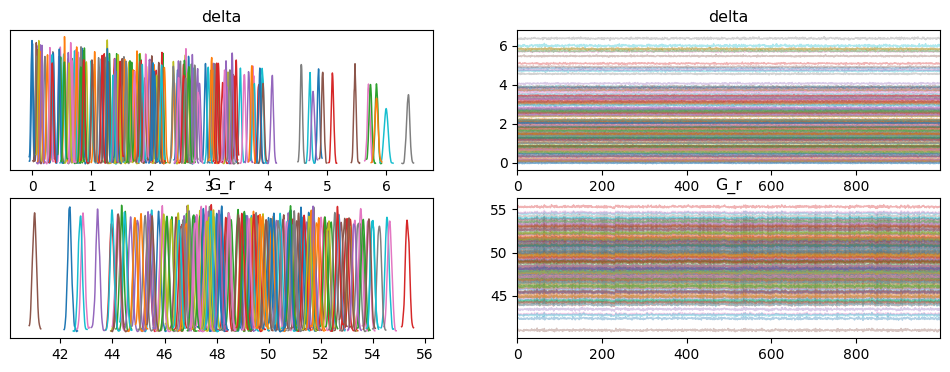

In [321]:
def make_positive_definite(cov_mat, epsilon=1e-6):
    # Ensure symmetry
    cov_mat = (cov_mat + cov_mat.T) / 2

    # Add jitter to diagonal
    jitter = epsilon * np.eye(cov_mat.shape[0])
    return cov_mat + jitter


def monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta):
    num_player = len(Wo_[0])

    cov_mat = make_positive_definite(cov_mat)

    with pm.Model() as model:
        L = np.linalg.cholesky(make_positive_definite(cov_mat))
        delta = pm.MvNormal("delta", mu=mu_delta, chol=L, shape=num_player)
        # delta = pm.MvNormal("delta", mu=mu_delta, cov=cov_mat, shape=num_player)

        # Compute 90th percentile of performance
        dot_product = pt.dot(Wo_, delta)
        G_r = pm.Deterministic("G_r",  np.percentile(dot_product, 90)) # pt.sort(dot_product)[-int(len(Wo_) * 0.9)])

        approx = pm.fit(method='advi', n=20000)

        trace = approx.sample(1000)
        # trace = pm.sample(
        #     3000,
        #     return_inferencedata=True,
        #     cores=2,
        #     chains=10,
        #     progressbar=True,
        #     target_accept=0.95
        # )

        # G_r_90 = np.percentile(pt.dot(trace.posterior['delta'].values, Wo_), 90)

    return trace
MC_sim_trace = monte_carlo_simulation(Wo_, mu_delta, cov_mat, sigma_delta)

az.plot_trace(MC_sim_trace, var_names=["delta", "G_r"])
az.summary(MC_sim_trace, var_names=["delta", "G_r"])

In [322]:
delta_samples = MC_sim_trace.posterior['delta'].stack(sample=("chain", "draw")).values.T  # shape (N_samples, 226)
G_r_samples   = MC_sim_trace.posterior['G_r'].stack(sample=("chain", "draw")).values.T    # shape (N_samples, 200)

G_r_scalar = np.percentile(G_r_samples, 90, axis=1)  # shape (N_samples,)
print(G_r_scalar.shape, delta_samples.shape)

mu_delta, cov_delta, mu_G, var_G, cov_delta_G, sigma_G = generate_cov_delta(delta_samples, G_r_scalar)


(1000,) (1000, 195)
(1000, 195) (1000,)


In [323]:
lambdas = np.linspace(0.0, 0.5, 6)
best_lambda, best_w, best_prob = optimize_portfolio(W_constraints, mu_delta, cov_delta, mu_G, var_G, cov_delta_G, lambdas, delta_samples, G_r_scalar, players_preds)
print(f"Best λ: {best_lambda}, Best Probability of Outperforming: {best_prob}")
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, fg_managers_38)
selected, player_names, total_points

195 195
195 195 {'Fulham', 'Brighton and Hove Albion', 'Sheffield United', 'Crystal Palace', 'Newcastle United', 'Nottingham Forest', 'Manchester United', 'Arsenal', 'Manchester City', 'Liverpool', 'Bournemouth', 'Luton', 'Tottenham Hotspur', 'Everton', 'Chelsea', 'West Ham United', 'Burnley', 'Aston Villa', 'Brentford', 'Wolverhampton Wanderers'}
Fulham [22, 30, 39, 77, 83, 164, 182] 7 195
Brighton and Hove Albion [4, 27, 31, 55, 70, 90, 109, 110, 124, 158, 175] 11 195
Sheffield United [15, 25, 29, 35, 86, 98, 188] 7 195
Crystal Palace [43, 56, 63, 89, 99, 100, 102, 105, 141, 151, 154, 185, 189] 13 195
Newcastle United [10, 20, 37, 52, 65, 66, 78, 88, 125, 136, 138, 173] 12 195
Nottingham Forest [19, 32, 36, 44, 76, 146, 170, 177, 191] 9 195
Manchester United [1, 6, 17, 45, 117, 137, 163, 174] 8 195
Arsenal [34, 57, 113, 121, 178, 181, 190] 7 195
Manchester City [49, 67, 85, 93, 104, 111, 115, 120, 131, 149, 161] 11 195
Liverpool [11, 16, 48, 61, 79, 95, 127, 145, 183, 186] 10 195
Bou

([19, 20, 60, 263, 308, 313, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Virgil van Dijk',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 102.0)

In [324]:
selected, player_names, total_points = selected_info(best_w, fpl_teams_ids, players_preds, fg_managers_38)
selected, player_names, total_points

[15.  8. 42.  3.  5.  2. 13.  2.  5.  1.  6.] ---------> [8.42857821 5.75904691 9.66969921 2.348      2.83085205 5.88199999
 4.82644648 2.12951213 3.48122268 1.42490824 5.19414667]
Your predicted player’s total of 102.0 points would rank:
→ Position: 9 out of 256 managers
→ Percentile: Top 96.48%

Closest scores around you:
   points     prize
0   104.0  R 199.50
1   104.0  R 199.50
2   102.0   R 99.75
3   102.0   R 99.75
4   100.5   R 20.32


([19, 20, 60, 263, 308, 313, 343, 353, 355, 362, 369],
 ['Bukayo Saka',
  'William Saliba',
  'Ollie Watkins',
  'Jordan Pickford',
  'Mohamed Salah',
  'Virgil van Dijk',
  'Julián Álvarez',
  'Phil Foden',
  'Erling Haaland',
  'Cole Palmer',
  'Kyle Walker'],
 102.0)